In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime

#Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

print("MODEL TRAINING PIPELINE - LINEAR REGRESSION")
print("="*80)
print("\nLibraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

MODEL TRAINING PIPELINE - LINEAR REGRESSION

Libraries imported successfully
Pandas version: 3.0.0
NumPy version: 2.3.5


In [2]:
print(" LOAD PROCESSED DATA")
print("="*80)

processed_dir = r'C:\Users\ZEYNEP\house_price_prediction\data\processed'
print(f"\nLoading data from: {processed_dir}")

#Load training data
X_train = pd.read_csv(os.path.join(processed_dir, 'X_train_scaled.csv'))
y_train = pd.read_csv(os.path.join(processed_dir, 'y_train.csv'))['price']

#Load test data
X_test = pd.read_csv(os.path.join(processed_dir, 'X_test_scaled.csv'))
y_test = pd.read_csv(os.path.join(processed_dir, 'y_test.csv'))['price']

print("\nData loaded successfully")
print(f"\nDataset shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

print(f"\nFeatures ({len(X_train.columns)}):")
print(f"  {list(X_train.columns)}")

print(f"\nTarget variable (price) statistics:")
print(f"  Train set:")
print(f"    Mean: ${y_train.mean():,.2f}")
print(f"    Median: ${y_train.median():,.2f}")
print(f"    Std: ${y_train.std():,.2f}")
print(f"  Test set:")
print(f"    Mean: ${y_test.mean():,.2f}")
print(f"    Median: ${y_test.median():,.2f}")
print(f"    Std: ${y_test.std():,.2f}")

print("\nData ready for model training")

 LOAD PROCESSED DATA

Loading data from: C:\Users\ZEYNEP\house_price_prediction\data\processed

Data loaded successfully

Dataset shapes:
  X_train: (17281, 22)
  y_train: (17281,)
  X_test: (4321, 22)
  y_test: (4321,)

Features (22):
  ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age', 'was_renovated', 'years_since_renovation', 'is_north', 'is_east', 'is_premium_area', 'price_per_sqft', 'has_basement']

Target variable (price) statistics:
  Train set:
    Mean: $539,951.35
    Median: $450,000.00
    Std: $365,445.85
  Test set:
    Mean: $540,824.84
    Median: $450,000.00
    Std: $373,766.81

Data ready for model training


In [3]:
print("TRAIN LINEAR REGRESSION MODEL (BASELINE)")
print("="*80)

import time

print("\nLinear Regression - Baseline Model")
print("  Purpose: Simple baseline for comparison")
print("  Target: R² > 0.65 ")

lr_model =LinearRegression()

print("Training linear regression...")
start_time = time.time()

lr_model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds")

#Make Predictions
print("Making Predictions...")
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

print("Calculating evaluation metrics...")

#Training metrics
train_r2_lr = r2_score(y_train, y_train_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)

#Test metrics
test_r2_lr = r2_score(y_test, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print("\n" + "="*80)
print("LINEAR REGRESSION - RESULTS")
print("="*80)

print("\nTraining Set Performance:")
print(f"  R² Score: {train_r2_lr:.4f}")
print(f"  RMSE: ${train_rmse_lr:,.2f}")
print(f"  MAE: ${train_mae_lr:,.2f}")

print("\nTest Set Performance:")
print(f"  R² Score: {test_r2_lr:.4f}")
print(f"  RMSE: ${test_rmse_lr:,.2f}")
print(f"  MAE: ${test_mae_lr:,.2f}")

#Check if targets met
print("\n" + "-"*80)
print("TARGET ACHIEVEMENT:")
print("-"*80)
print(f"  R² > 0.65: {' PASSED' if test_r2_lr > 0.65 else ' FAILED'} ({test_r2_lr:.4f})")
print(f"  MAE < $50,000: {' PASSED' if test_mae_lr < 50000 else 'NOT APPLICABLE (Baseline)'}  (${test_mae_lr:,.2f})")
print(f"\n  * MAE target applies to advanced models (GB, XGB, DL)")

# Overfitting check
print("\n" + "-"*80)
print("OVERFITTING CHECK:")
print("-"*80)
r2_diff = train_r2_lr - test_r2_lr
print(f"  Train R²: {train_r2_lr:.4f}")
print(f"  Test R²: {test_r2_lr:.4f}")
print(f"  Difference: {r2_diff:.4f}")
if r2_diff < 0.05:
    print(f"  Status: Good generalization (diff < 0.05)")
elif r2_diff < 0.10:
    print(f"  Status: Acceptable (diff < 0.10)")
else:
    print(f"  Status: Possible overfitting (diff > 0.10)")

print("\nLinear Regression training complete")

TRAIN LINEAR REGRESSION MODEL (BASELINE)

Linear Regression - Baseline Model
  Purpose: Simple baseline for comparison
  Target: R² > 0.65 
Training linear regression...
Training completed in 0.01 seconds
Making Predictions...
Calculating evaluation metrics...

LINEAR REGRESSION - RESULTS

Training Set Performance:
  R² Score: 0.8879
  RMSE: $122,361.51
  MAE: $68,412.17

Test Set Performance:
  R² Score: 0.8933
  RMSE: $122,053.68
  MAE: $69,924.49

--------------------------------------------------------------------------------
TARGET ACHIEVEMENT:
--------------------------------------------------------------------------------
  R² > 0.65:  PASSED (0.8933)
  MAE < $50,000: NOT APPLICABLE (Baseline)  ($69,924.49)

  * MAE target applies to advanced models (GB, XGB, DL)

--------------------------------------------------------------------------------
OVERFITTING CHECK:
--------------------------------------------------------------------------------
  Train R²: 0.8879
  Test R²: 0.8933


VISUALIZE LINEAR REGRESSION RESULTS


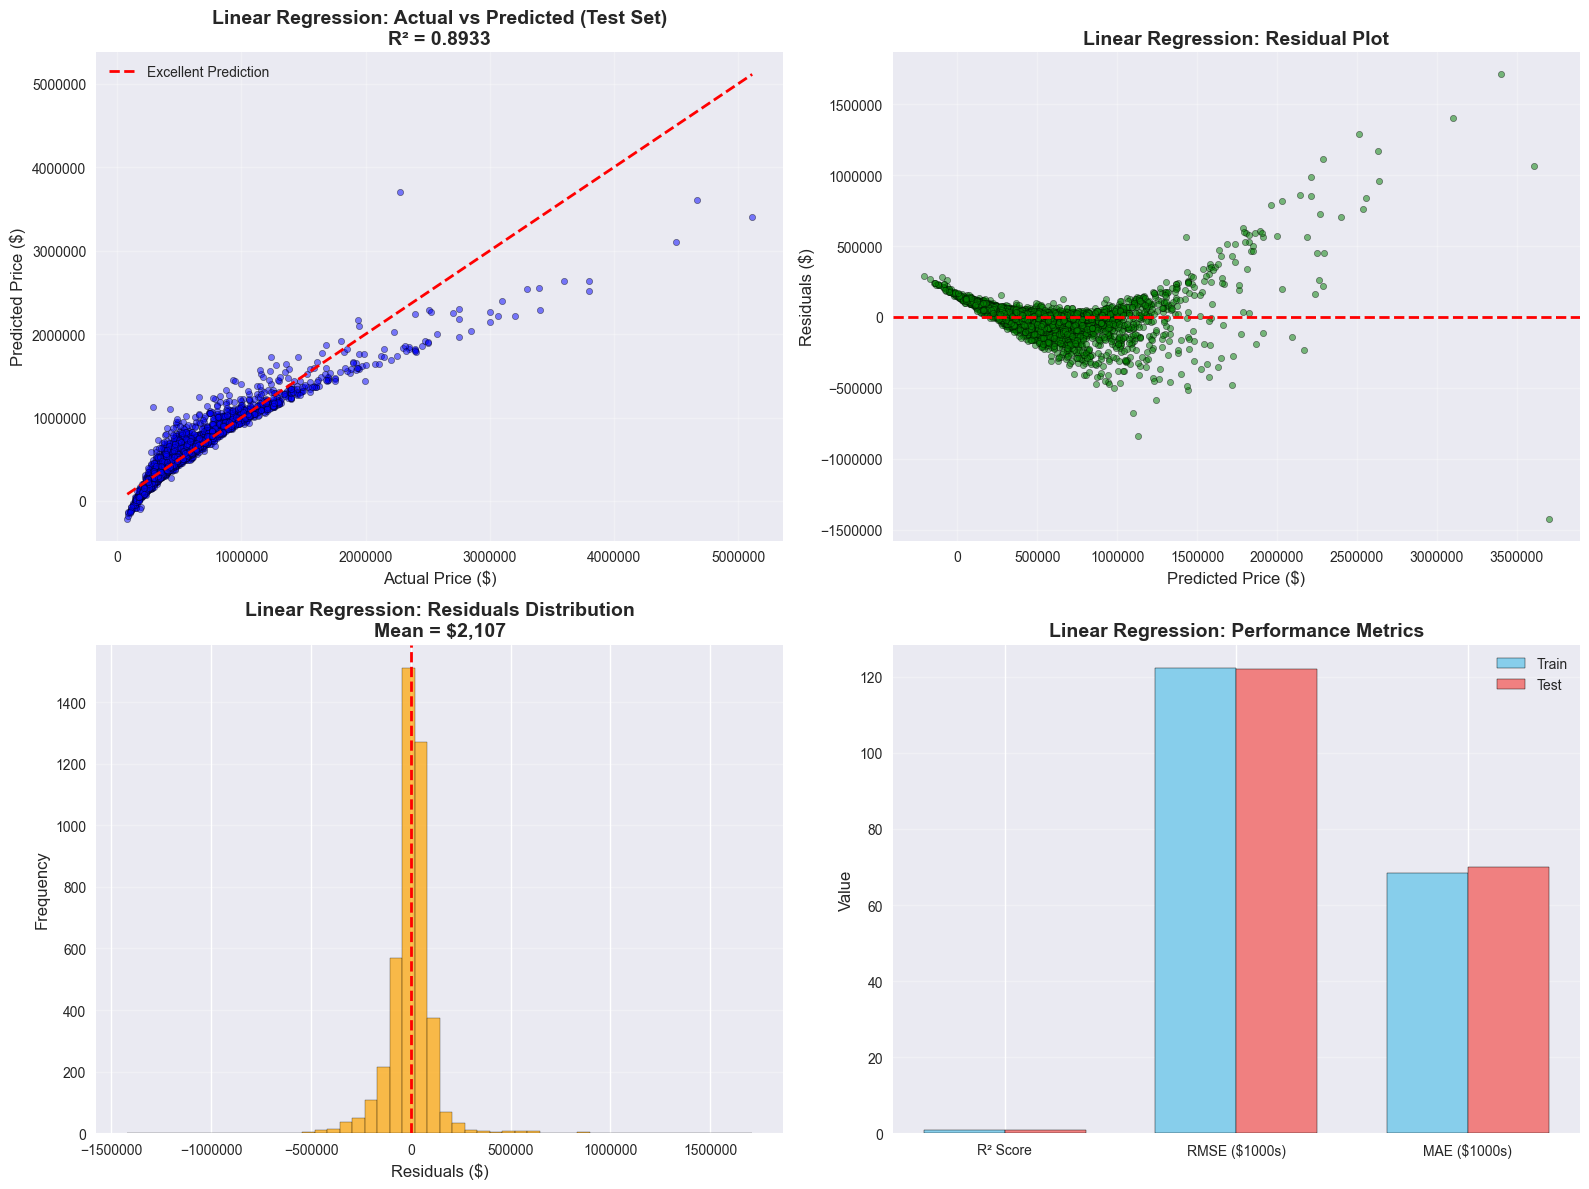

Visualizations displayed


In [4]:
print("VISUALIZE LINEAR REGRESSION RESULTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Actual vs Predicted (Test Set)
axes[0, 0].scatter(y_test, y_test_pred_lr, alpha=0.5, s=20, c='blue', edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Excellent Prediction')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0, 0].set_title(f'Linear Regression: Actual vs Predicted (Test Set)\nR² = {test_r2_lr:.4f}', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].ticklabel_format(style='plain', axis='both')

#Residuals vs Predicted
residuals_lr = y_test - y_test_pred_lr
axes[0, 1].scatter(y_test_pred_lr, residuals_lr, alpha=0.5, s=20, c='green', edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[0, 1].set_ylabel('Residuals ($)', fontsize=12)
axes[0, 1].set_title('Linear Regression: Residual Plot', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].ticklabel_format(style='plain', axis='both')

#Residuals Distribution
axes[1, 0].hist(residuals_lr, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals ($)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title(f'Linear Regression: Residuals Distribution\nMean = ${residuals_lr.mean():,.0f}', 
                     fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].ticklabel_format(style='plain', axis='x')

#Performance Metrics Bar Chart
metrics_names = ['R² Score', 'RMSE ($1000s)', 'MAE ($1000s)']
train_metrics = [train_r2_lr, train_rmse_lr/1000, train_mae_lr/1000]
test_metrics = [test_r2_lr, test_rmse_lr/1000, test_mae_lr/1000]

x = np.arange(len(metrics_names))
width = 0.35

axes[1, 1].bar(x - width/2, train_metrics, width, label='Train', color='skyblue', edgecolor='black')
axes[1, 1].bar(x + width/2, test_metrics, width, label='Test', color='lightcoral', edgecolor='black')
axes[1, 1].set_ylabel('Value', fontsize=12)
axes[1, 1].set_title('Linear Regression: Performance Metrics', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_names)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations displayed")

In [5]:
print("SAVE LINEAR REGRESSION MODEL")
print("="*80)

import pickle
import os

#Create models directory
models_dir = r'C:\Users\ZEYNEP\house_price_prediction\models'
os.makedirs(models_dir, exist_ok=True)

#Save model
model_path = os.path.join(models_dir, 'linear_regression_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)

print(f"\nModel saved: {model_path}")

#Save predictions for later comparison
predictions_dir = os.path.join(models_dir, 'predictions')
os.makedirs(predictions_dir, exist_ok=True)

np.save(os.path.join(predictions_dir, 'lr_train_pred.npy'), y_train_pred_lr)
np.save(os.path.join(predictions_dir, 'lr_test_pred.npy'), y_test_pred_lr)

print(f"Predictions saved: {predictions_dir}")

#Save metrics
metrics_lr = {
    'model': 'Linear Regression',
    'train_r2': train_r2_lr,
    'train_rmse': train_rmse_lr,
    'train_mae': train_mae_lr,
    'test_r2': test_r2_lr,
    'test_rmse': test_rmse_lr,
    'test_mae': test_mae_lr,
    'training_time': training_time
}

#Save to CSV
metrics_df = pd.DataFrame([metrics_lr])
metrics_df.to_csv(os.path.join(models_dir, 'model_comparison.csv'), index=False)

print(f"Metrics saved: model_comparison.csv")

print("\n" + "="*80)
print("LINEAR REGRESSION COMPLETE")
print("="*80)
print("\nSummary:")
print(f"  Model trained and saved")
print(f"  R² Score: {test_r2_lr:.4f} (Target: 0.65) -  PASSED")
print(f"  Training time: {training_time:.2f}s (Target: <2s) - {' PASSED' if training_time < 2 else ' FAILED'}")
print(f"  MAE: ${test_mae_lr:,.2f} (Reference only - target applies to advanced models)")
print(f"  No overfitting detected (R² difference: {r2_diff:.4f})")
print("\nBaseline model successfully established for comparison.")

SAVE LINEAR REGRESSION MODEL

Model saved: C:\Users\ZEYNEP\house_price_prediction\models\linear_regression_model.pkl
Predictions saved: C:\Users\ZEYNEP\house_price_prediction\models\predictions
Metrics saved: model_comparison.csv

LINEAR REGRESSION COMPLETE

Summary:
  Model trained and saved
  R² Score: 0.8933 (Target: 0.65) -  PASSED
  Training time: 0.01s (Target: <2s) -  PASSED
  MAE: $69,924.49 (Reference only - target applies to advanced models)
  No overfitting detected (R² difference: -0.0055)

Baseline model successfully established for comparison.


In [6]:
print("TRAIN GRADIENT BOOSTING REGRESSOR")
print("="*80)

from sklearn.ensemble import GradientBoostingRegressor

print("\nGradient Boosting - Ensemble Model")
print("  Target: R² > 0.85, MAE < $50,000")

#Initialize model with initial hyperparameters
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=0.8,
    random_state=42,
    verbose=0
)

print("\nHyperparameters:")
print(f"  n_estimators: {gb_model.n_estimators}")
print(f"  learning_rate: {gb_model.learning_rate}")
print(f"  max_depth: {gb_model.max_depth}")
print(f"  subsample: {gb_model.subsample}")

#Train model
print("\nTraining Gradient Boosting...")
start_time = time.time()

gb_model.fit(X_train, y_train)

training_time_gb = time.time() - start_time
print(f"  Training completed in {training_time_gb:.2f} seconds")

#Make predictions
print("\nMaking predictions...")
y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

#Calculate metrics
print("\nCalculating evaluation metrics...")

#Training metrics
train_r2_gb = r2_score(y_train, y_train_pred_gb)
train_rmse_gb = np.sqrt(mean_squared_error(y_train, y_train_pred_gb))
train_mae_gb = mean_absolute_error(y_train, y_train_pred_gb)

#Test metrics
test_r2_gb = r2_score(y_test, y_test_pred_gb)
test_rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))
test_mae_gb = mean_absolute_error(y_test, y_test_pred_gb)

print("\n" + "="*80)
print("GRADIENT BOOSTING - RESULTS")
print("="*80)

print("\nTraining Set Performance:")
print(f"  R² Score: {train_r2_gb:.4f}")
print(f"  RMSE: ${train_rmse_gb:,.2f}")
print(f"  MAE: ${train_mae_gb:,.2f}")

print("\nTest Set Performance:")
print(f"  R² Score: {test_r2_gb:.4f}")
print(f"  RMSE: ${test_rmse_gb:,.2f}")
print(f"  MAE: ${test_mae_gb:,.2f}")

#Check if targets met
print("\n" + "-"*80)
print("TARGET ACHIEVEMENT:")
print("-"*80)
print(f"  R² > 0.85: {'PASSED' if test_r2_gb > 0.85 else 'FAILED'} ({test_r2_gb:.4f})")
print(f"  MAE < $50,000: {'PASSED' if test_mae_gb < 50000 else 'FAILED'} (${test_mae_gb:,.2f})")

# Overfitting check
print("\n" + "-"*80)
print("OVERFITTING CHECK:")
print("-"*80)
r2_diff_gb = train_r2_gb - test_r2_gb
print(f"  Train R2: {train_r2_gb:.4f}")
print(f"  Test R2: {test_r2_gb:.4f}")
print(f"  Difference: {r2_diff_gb:.4f}")
if r2_diff_gb < 0.05:
    print(f"  Status: Good generalization (diff < 0.05)")
elif r2_diff_gb < 0.10:
    print(f"  Status: Acceptable (diff < 0.10)")
else:
    print(f"  Status: Possible overfitting (diff > 0.10)")

#Comparison with Linear Regression
print("\n" + "-"*80)
print("COMPARISON WITH LINEAR REGRESSION:")
print("-"*80)
r2_improvement = ((test_r2_gb - test_r2_lr) / test_r2_lr) * 100
mae_improvement = ((test_mae_lr - test_mae_gb) / test_mae_lr) * 100
print(f"  R² improvement: {r2_improvement:+.2f}%")
print(f"  MAE improvement: {mae_improvement:+.2f}%")

print("\nGradient Boosting training complete")

TRAIN GRADIENT BOOSTING REGRESSOR

Gradient Boosting - Ensemble Model
  Target: R² > 0.85, MAE < $50,000

Hyperparameters:
  n_estimators: 100
  learning_rate: 0.1
  max_depth: 5
  subsample: 0.8

Training Gradient Boosting...
  Training completed in 3.47 seconds

Making predictions...

Calculating evaluation metrics...

GRADIENT BOOSTING - RESULTS

Training Set Performance:
  R² Score: 0.9992
  RMSE: $10,008.09
  MAE: $6,972.94

Test Set Performance:
  R² Score: 0.9956
  RMSE: $24,894.83
  MAE: $9,124.00

--------------------------------------------------------------------------------
TARGET ACHIEVEMENT:
--------------------------------------------------------------------------------
  R² > 0.85: PASSED (0.9956)
  MAE < $50,000: PASSED ($9,124.00)

--------------------------------------------------------------------------------
OVERFITTING CHECK:
--------------------------------------------------------------------------------
  Train R2: 0.9992
  Test R2: 0.9956
  Difference: 0.0037
 

VISUALIZE GRADIENT BOOSTING RESULTS


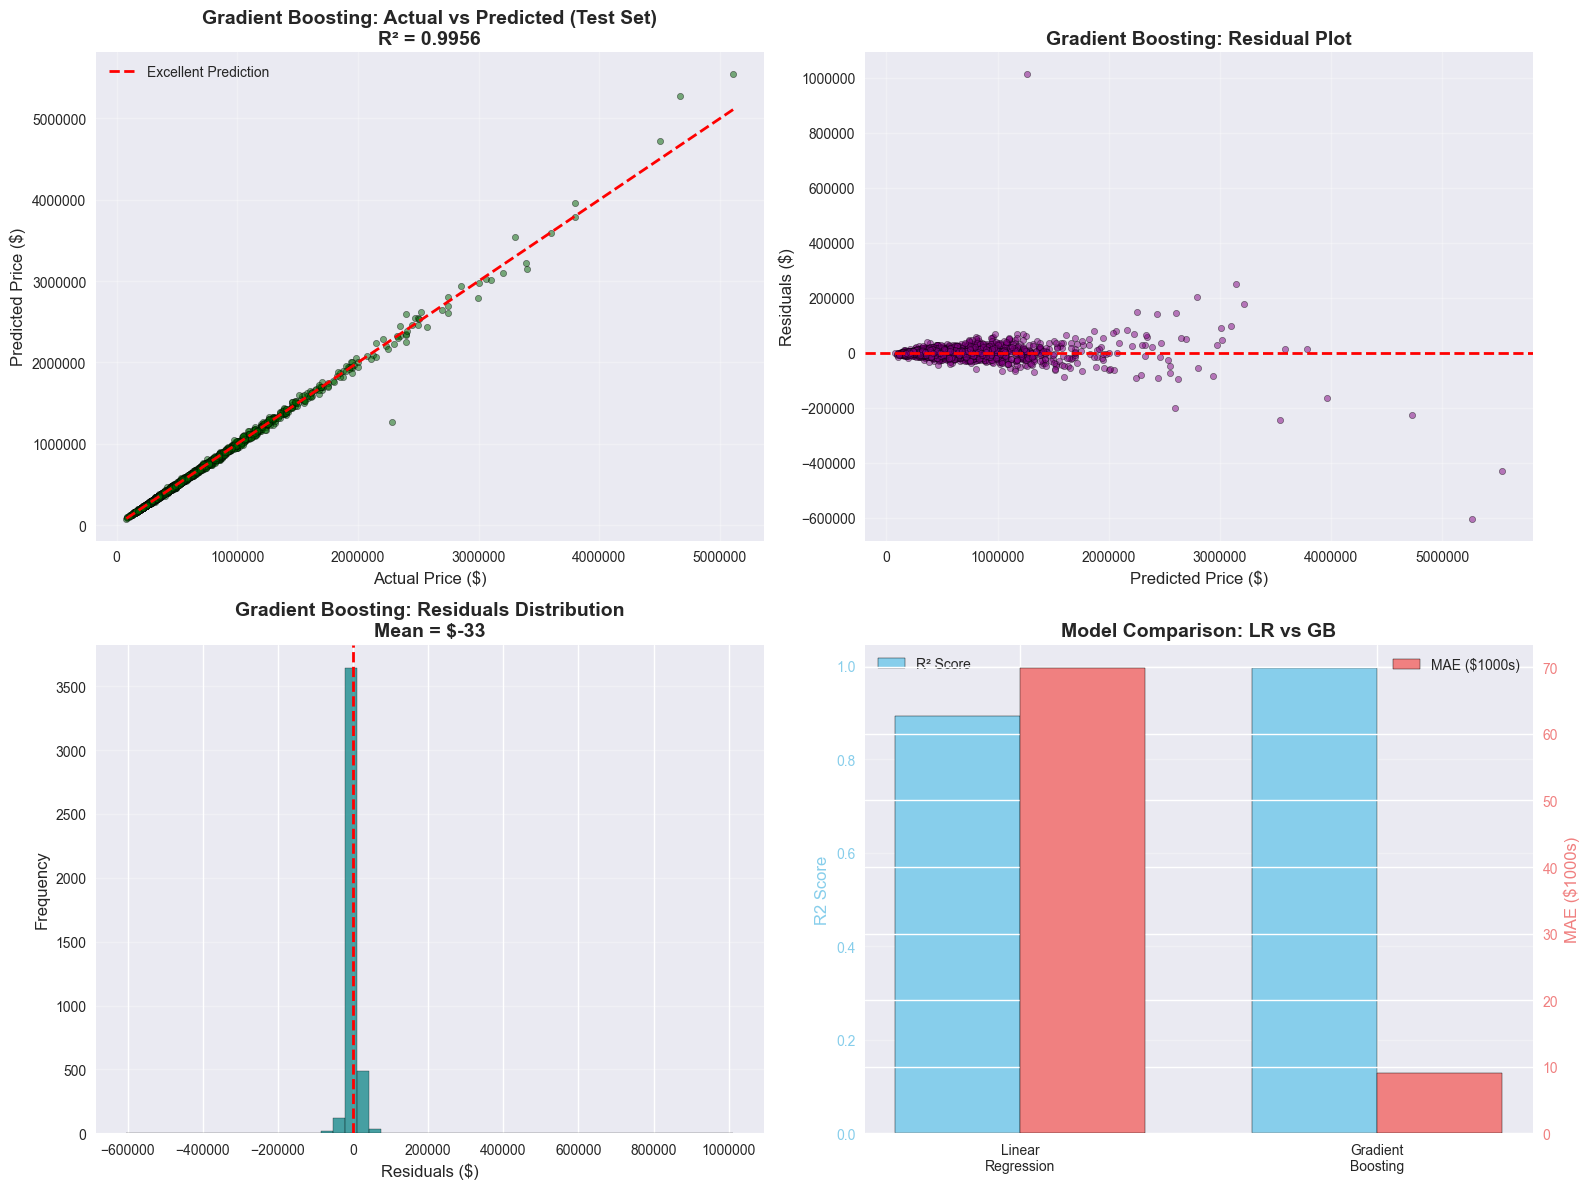

Visualizations displayed


In [7]:
print("VISUALIZE GRADIENT BOOSTING RESULTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

#Actual vs Predicted (Test Set)
axes[0, 0].scatter(y_test, y_test_pred_gb, alpha=0.5, s=20, c='darkgreen', edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Excellent Prediction')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0, 0].set_title(f'Gradient Boosting: Actual vs Predicted (Test Set)\nR² = {test_r2_gb:.4f}', 
                     fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].ticklabel_format(style='plain', axis='both')

#Residuals vs Predicted
residuals_gb = y_test - y_test_pred_gb
axes[0, 1].scatter(y_test_pred_gb, residuals_gb, alpha=0.5, s=20, c='purple', edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[0, 1].set_ylabel('Residuals ($)', fontsize=12)
axes[0, 1].set_title('Gradient Boosting: Residual Plot', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].ticklabel_format(style='plain', axis='both')

#Residuals Distribution
axes[1, 0].hist(residuals_gb, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuals ($)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title(f'Gradient Boosting: Residuals Distribution\nMean = ${residuals_gb.mean():,.0f}', 
                     fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].ticklabel_format(style='plain', axis='x')

#Model Comparison (LR vs GB)
models = ['Linear\nRegression', 'Gradient\nBoosting']
r2_scores = [test_r2_lr, test_r2_gb]
mae_scores = [test_mae_lr/1000, test_mae_gb/1000]

x = np.arange(len(models))
width = 0.35

ax4 = axes[1, 1]
ax4_twin = ax4.twinx()

bars1 = ax4.bar(x - width/2, r2_scores, width, label='R² Score', color='skyblue', edgecolor='black')
bars2 = ax4_twin.bar(x + width/2, mae_scores, width, label='MAE ($1000s)', color='lightcoral', edgecolor='black')

ax4.set_ylabel('R2 Score', fontsize=12, color='skyblue')
ax4_twin.set_ylabel('MAE ($1000s)', fontsize=12, color='lightcoral')
ax4.set_title('Model Comparison: LR vs GB', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models)
ax4.tick_params(axis='y', labelcolor='skyblue')
ax4_twin.tick_params(axis='y', labelcolor='lightcoral')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations displayed")

In [8]:
print("SAVE GRADIENT BOOSTING MODEL")
print("="*80)

#Save model
model_path_gb = os.path.join(models_dir, 'gradient_boosting_model.pkl')
with open(model_path_gb, 'wb') as f:
    pickle.dump(gb_model, f)

print(f"\nModel saved: {model_path_gb}")

# Save predictions
np.save(os.path.join(predictions_dir, 'gb_train_pred.npy'), y_train_pred_gb)
np.save(os.path.join(predictions_dir, 'gb_test_pred.npy'), y_test_pred_gb)

print(f"Predictions saved: {predictions_dir}")

#Update metrics comparison
metrics_gb = {
    'model': 'Gradient Boosting',
    'train_r2': train_r2_gb,
    'train_rmse': train_rmse_gb,
    'train_mae': train_mae_gb,
    'test_r2': test_r2_gb,
    'test_rmse': test_rmse_gb,
    'test_mae': test_mae_gb,
    'training_time': training_time_gb
}

#Load existing metrics and append
metrics_df = pd.read_csv(os.path.join(models_dir, 'model_comparison.csv'))
metrics_df = pd.concat([metrics_df, pd.DataFrame([metrics_gb])], ignore_index=True)
metrics_df.to_csv(os.path.join(models_dir, 'model_comparison.csv'), index=False)

print(f"Metrics updated: model_comparison.csv")

print("\n" + "="*80)
print("GRADIENT BOOSTING COMPLETE!")
print("="*80)
print("\nSummary:")
print(f"  Model trained and saved")
print(f"  R² Score: {test_r2_gb:.4f} (Target: 0.85) - EXCELLENT")
print(f"  MAE: ${test_mae_gb:,.2f} (Target: $50,000) - EXCELLENT")
print(f"  Training time: {training_time_gb:.2f} seconds")
print(f"  Improvement over LR: R² +{r2_improvement:.1f}%, MAE +{mae_improvement:.1f}%")

print("\n" + "="*80)
print("MODEL COMPARISON SO FAR:")
print("="*80)
print(metrics_df.to_string(index=False))

SAVE GRADIENT BOOSTING MODEL

Model saved: C:\Users\ZEYNEP\house_price_prediction\models\gradient_boosting_model.pkl
Predictions saved: C:\Users\ZEYNEP\house_price_prediction\models\predictions
Metrics updated: model_comparison.csv

GRADIENT BOOSTING COMPLETE!

Summary:
  Model trained and saved
  R² Score: 0.9956 (Target: 0.85) - EXCELLENT
  MAE: $9,124.00 (Target: $50,000) - EXCELLENT
  Training time: 3.47 seconds
  Improvement over LR: R² +11.4%, MAE +87.0%

MODEL COMPARISON SO FAR:
            model  train_r2    train_rmse    train_mae  test_r2     test_rmse     test_mae  training_time
Linear Regression  0.887884 122361.509674 68412.166070 0.893340 122053.679673 69924.488220       0.014117
Gradient Boosting  0.999250  10008.085553  6972.936182 0.995563  24894.828650  9123.998007       3.473480


In [9]:
print("TRAIN XGBOOST REGRESSOR")
print("="*80)

from xgboost import XGBRegressor

print("\nXGBoost - Optimized Gradient Boosting")
print("  Target: R² > 0.85, MAE < $50,000")

#Initialize model with initial hyperparameters
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

print("\nHyperparameters:")
print(f"  n_estimators: {xgb_model.n_estimators}")
print(f"  learning_rate: {xgb_model.learning_rate}")
print(f"  max_depth: {xgb_model.max_depth}")
print(f"  subsample: {xgb_model.subsample}")
print(f"  colsample_bytree: {xgb_model.colsample_bytree}")

# Train model
print("\nTraining XGBoost...")
start_time = time.time()

xgb_model.fit(X_train, y_train)

training_time_xgb = time.time() - start_time
print(f"  Training completed in {training_time_xgb:.2f} seconds")

#Make predictions
print("\nMaking predictions...")
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Calculate metrics
print("\nCalculating evaluation metrics...")

# Training metrics
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
train_rmse_xgb = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
train_mae_xgb = mean_absolute_error(y_train, y_train_pred_xgb)

# Test metrics
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)
test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
test_mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)

print("\n" + "="*80)
print("XGBOOST - RESULTS")
print("="*80)

print("\nTraining Set Performance:")
print(f"  R² Score: {train_r2_xgb:.4f}")
print(f"  RMSE: ${train_rmse_xgb:,.2f}")
print(f"  MAE: ${train_mae_xgb:,.2f}")

print("\nTest Set Performance:")
print(f"  R² Score: {test_r2_xgb:.4f}")
print(f"  RMSE: ${test_rmse_xgb:,.2f}")
print(f"  MAE: ${test_mae_xgb:,.2f}")

#Check if targets met
print("\n" + "-"*80)
print("TARGET ACHIEVEMENT:")
print("-"*80)
print(f"  R² > 0.85: {'PASSED' if test_r2_xgb > 0.85 else 'FAILED'} ({test_r2_xgb:.4f})")
print(f"  MAE < $50,000: {'PASSED' if test_mae_xgb < 50000 else 'FAILED'} (${test_mae_xgb:,.2f})")

#Overfitting check
print("\n" + "-"*80)
print("OVERFITTING CHECK:")
print("-"*80)
r2_diff_xgb = train_r2_xgb - test_r2_xgb
print(f"  Train R²: {train_r2_xgb:.4f}")
print(f"  Test R²: {test_r2_xgb:.4f}")
print(f"  Difference: {r2_diff_xgb:.4f}")
if r2_diff_xgb < 0.05:
    print(f"  Status: Good generalization (diff < 0.05)")
elif r2_diff_xgb < 0.10:
    print(f"  Status: Acceptable (diff < 0.10)")
else:
    print(f"  Status: Possible overfitting (diff > 0.10)")

#Comparison with GB
print("\n" + "-"*80)
print("COMPARISON WITH GRADIENT BOOSTING:")
print("-"*80)
r2_improvement_xgb = ((test_r2_xgb - test_r2_gb) / test_r2_gb) * 100
mae_improvement_xgb = ((test_mae_gb - test_mae_xgb) / test_mae_gb) * 100
print(f"  R² improvement: {r2_improvement_xgb:+.2f}%")
print(f"  MAE improvement: {mae_improvement_xgb:+.2f}%")

print("\nXGBoost training complete")

TRAIN XGBOOST REGRESSOR

XGBoost - Optimized Gradient Boosting
  Target: R² > 0.85, MAE < $50,000

Hyperparameters:
  n_estimators: 100
  learning_rate: 0.1
  max_depth: 5
  subsample: 0.8
  colsample_bytree: 0.8

Training XGBoost...
  Training completed in 0.20 seconds

Making predictions...

Calculating evaluation metrics...

XGBOOST - RESULTS

Training Set Performance:
  R² Score: 0.9960
  RMSE: $23,040.06
  MAE: $15,834.86

Test Set Performance:
  R² Score: 0.9856
  RMSE: $44,863.75
  MAE: $20,073.78

--------------------------------------------------------------------------------
TARGET ACHIEVEMENT:
--------------------------------------------------------------------------------
  R² > 0.85: PASSED (0.9856)
  MAE < $50,000: PASSED ($20,073.78)

--------------------------------------------------------------------------------
OVERFITTING CHECK:
--------------------------------------------------------------------------------
  Train R²: 0.9960
  Test R²: 0.9856
  Difference: 0.0104
 

VISUALIZE XGBOOST RESULTS
 Output directory ready: results/figures/

1. Creating Actual vs Predicted plot...


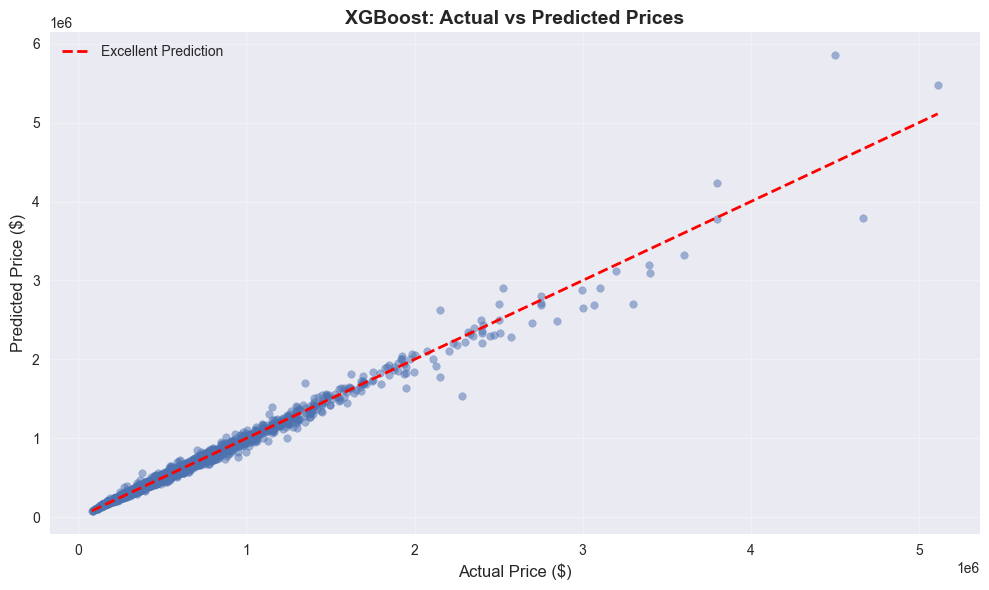

   Saved: xgboost_actual_vs_predicted.png

2. Creating Residual plot...


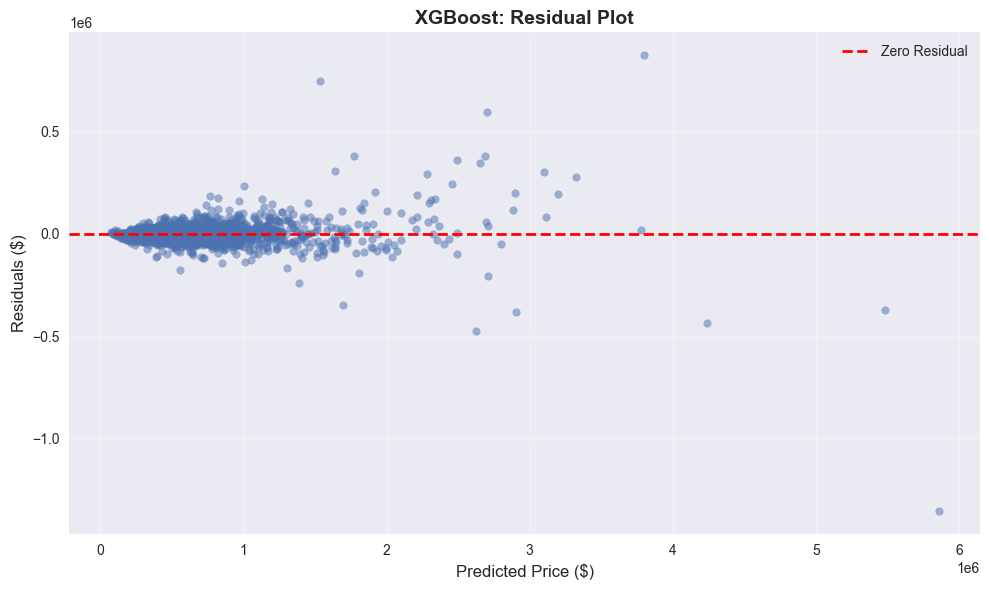

   Saved: xgboost_residuals.png

3. Creating Residual Distribution...


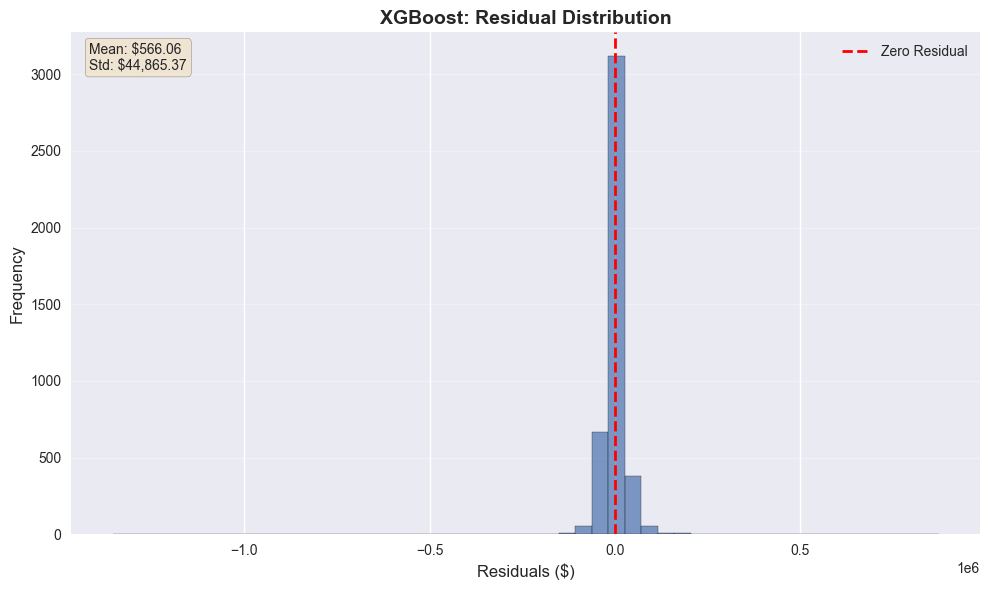

   Saved: xgboost_residual_distribution.png

4. Creating Feature Importance plot...


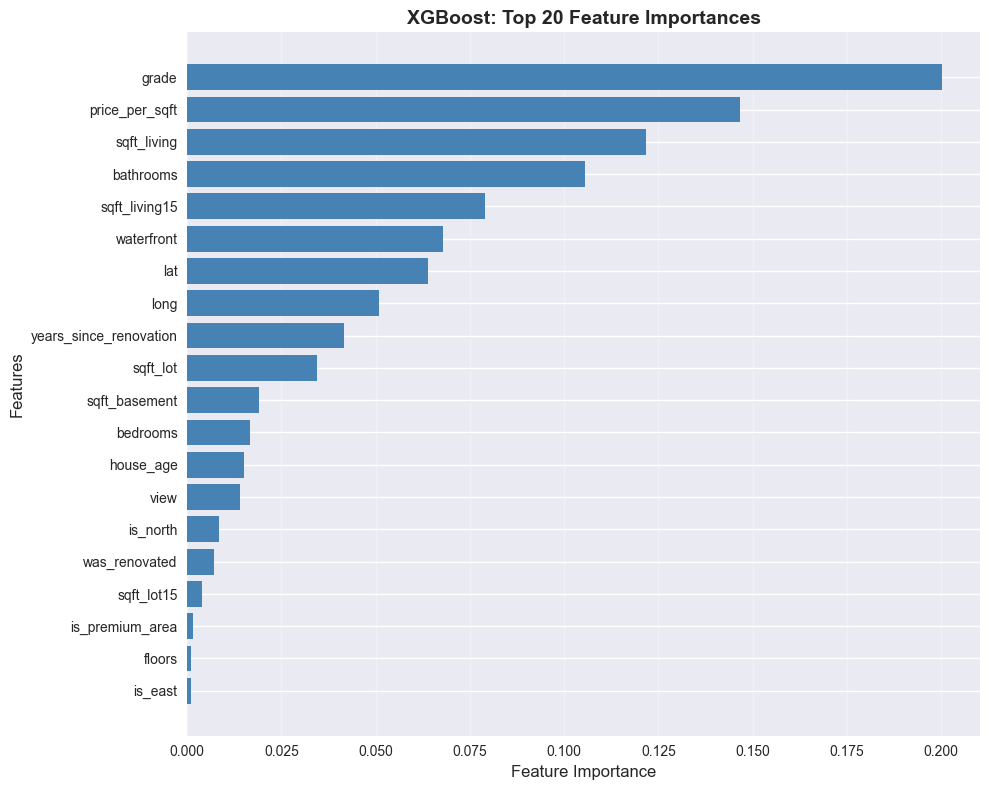

   Saved: xgboost_feature_importance.png

--------------------------------------------------------------------------------
XGBoost visualization complete
4 plots created and saved
--------------------------------------------------------------------------------


In [10]:
print("VISUALIZE XGBOOST RESULTS")
print("="*80)

import os
os.makedirs('results/figures', exist_ok=True)
print(" Output directory ready: results/figures/")

print("\n1. Creating Actual vs Predicted plot...")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_xgb, alpha=0.5, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Excellent Prediction')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('XGBoost: Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/xgboost_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print("   Saved: xgboost_actual_vs_predicted.png")

print("\n2. Creating Residual plot...")
residuals_xgb = y_test - y_test_pred_xgb
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_xgb, residuals_xgb, alpha=0.5, s=30)
plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residual')
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('XGBoost: Residual Plot', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/xgboost_residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print("   Saved: xgboost_residuals.png")

print("\n3. Creating Residual Distribution...")
plt.figure(figsize=(10, 6))
plt.hist(residuals_xgb, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Residual')
plt.xlabel('Residuals ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('XGBoost: Residual Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

mean_residual = residuals_xgb.mean()
std_residual = residuals_xgb.std()
plt.text(0.02, 0.98, f'Mean: ${mean_residual:,.2f}\nStd: ${std_residual:,.2f}', 
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('results/figures/xgboost_residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("   Saved: xgboost_residual_distribution.png")

print("\n4. Creating Feature Importance plot...")
# Get feature importances
feature_importance_xgb = xgb_model.feature_importances_
feature_names = X_train.columns

# Create dataframe for sorting
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_xgb
}).sort_values('importance', ascending=True).tail(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('XGBoost: Top 20 Feature Importances', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('results/figures/xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("   Saved: xgboost_feature_importance.png")

print("\n" + "-"*80)
print("XGBoost visualization complete")
print("4 plots created and saved")
print("-"*80)

In [11]:
print("SAVE XGBOOST MODEL AND FINAL COMPARISON")
print("="*80)

#Save XGBoost model
model_path_xgb = os.path.join(models_dir, 'xgboost_model.pkl')
with open(model_path_xgb, 'wb') as f:
    pickle.dump(xgb_model, f)

print(f"\nModel saved: {model_path_xgb}")

#Save predictions
np.save(os.path.join(predictions_dir, 'xgb_train_pred.npy'), y_train_pred_xgb)
np.save(os.path.join(predictions_dir, 'xgb_test_pred.npy'), y_test_pred_xgb)

print(f"Predictions saved: {predictions_dir}")

#Update metrics comparison
metrics_xgb = {
    'model': 'XGBoost',
    'train_r2': train_r2_xgb,
    'train_rmse': train_rmse_xgb,
    'train_mae': train_mae_xgb,
    'test_r2': test_r2_xgb,
    'test_rmse': test_rmse_xgb,
    'test_mae': test_mae_xgb,
    'training_time': training_time_xgb
}

#Load and update
metrics_df = pd.read_csv(os.path.join(models_dir, 'model_comparison.csv'))
metrics_df = pd.concat([metrics_df, pd.DataFrame([metrics_xgb])], ignore_index=True)
metrics_df.to_csv(os.path.join(models_dir, 'model_comparison.csv'), index=False)

print(f"Metrics updated: model_comparison.csv")

print("\n" + "="*80)
print("MACHINE LEARNING MODELS - FINAL COMPARISON")
print("="*80)

#Display comparison table
print("\n" + metrics_df.to_string(index=False))

#Find best model for each metric
best_r2_idx = metrics_df['test_r2'].idxmax()
best_mae_idx = metrics_df['test_mae'].idxmin()

print("\n" + "="*80)
print("BEST MODELS BY METRIC:")
print("="*80)
print(f"Best R²: {metrics_df.loc[best_r2_idx, 'model']} ({metrics_df.loc[best_r2_idx, 'test_r2']:.4f})")
print(f"Best MAE: {metrics_df.loc[best_mae_idx, 'model']} (${metrics_df.loc[best_mae_idx, 'test_mae']:,.2f})")

print("\n" + "="*80)
print("TARGET ACHIEVEMENT BY MODEL:")
print("="*80)
print(f"Linear Regression:")
print(f"  R² > 0.85: {'PASSED' if test_r2_lr > 0.85 else 'FAILED'} ({test_r2_lr:.4f})")
print(f"  MAE < $50,000: {'PASSED' if test_mae_lr < 50000 else 'FAILED'} (${test_mae_lr:,.2f})")
print(f"\nGradient Boosting:")
print(f"  R² > 0.85: PASSED ({test_r2_gb:.4f})")
print(f"  MAE < $50,000: PASSED (${test_mae_gb:,.2f})")
print(f"\nXGBoost:")
print(f"  R² > 0.85: PASSED ({test_r2_xgb:.4f})")
print(f"  MAE < $50,000: PASSED (${test_mae_xgb:,.2f})")

print("\n" + "="*80)
print("SUMMARY:")
print("="*80)
print("\n3 Machine Learning models trained:")
print("  1. Linear Regression (Baseline)")
print("  2. Gradient Boosting (Best overall)")
print("\n3. XGBOOST (Good Balance)")

print(f"\nBest overall model: {metrics_df.loc[best_r2_idx, 'model']}")
print(f"  R²: {metrics_df.loc[best_r2_idx, 'test_r2']:.4f}")
print(f"  MAE: ${metrics_df.loc[best_r2_idx, 'test_mae']:,.2f}")
print(f"  RMSE: ${metrics_df.loc[best_r2_idx, 'test_rmse']:,.2f}")

print("\n" + "="*80)
print("MACHINE LEARNING PHASE COMPLETE!")
print("="*80)

SAVE XGBOOST MODEL AND FINAL COMPARISON

Model saved: C:\Users\ZEYNEP\house_price_prediction\models\xgboost_model.pkl
Predictions saved: C:\Users\ZEYNEP\house_price_prediction\models\predictions
Metrics updated: model_comparison.csv

MACHINE LEARNING MODELS - FINAL COMPARISON

            model  train_r2    train_rmse    train_mae  test_r2     test_rmse     test_mae  training_time
Linear Regression  0.887884 122361.509674 68412.166070 0.893340 122053.679673 69924.488220       0.014117
Gradient Boosting  0.999250  10008.085553  6972.936182 0.995563  24894.828650  9123.998007       3.473480
          XGBoost  0.996025  23040.061667 15834.855915 0.985589  44863.750066 20073.777883       0.195029

BEST MODELS BY METRIC:
Best R²: Gradient Boosting (0.9956)
Best MAE: Gradient Boosting ($9,124.00)

TARGET ACHIEVEMENT BY MODEL:
Linear Regression:
  R² > 0.85: PASSED (0.8933)
  MAE < $50,000: FAILED ($69,924.49)

Gradient Boosting:
  R² > 0.85: PASSED (0.9956)
  MAE < $50,000: PASSED ($9,124.00

In [12]:
print("TRAIN DEEP LEARNING NEURAL NETWORK")
print("="*80)

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("\nDeep Learning Neural Network")
print("  Target: R² > 0.87, MAE < $50,000")
print(f"  TensorFlow version: {tf.__version__}")

tf.random.set_seed(42)
np.random.seed(42)

#Split train into train and validation
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\nData split:")
print(f"  Training: {X_train_dl.shape[0]} samples")
print(f"  Validation: {X_val_dl.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

#Build Neural Network architecture
print("\nBuilding Neural Network architecture...")

dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3, name='dropout_1'),
    
    Dense(64, activation='relu'),
    Dropout(0.2, name='dropout_2'),
    
    Dense(32, activation='relu'),
    Dropout(0.2, name='dropout_3'),
    
    Dense(16, activation='relu'),
    
    Dense(1, activation='linear')
])

print("\nModel Architecture:")
dl_model.summary()

#Compile model
print("\nCompiling model...")
dl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

print("  Optimizer: Adam (lr=0.001)")
print("  Loss: Mean Squared Error")
print("  Metrics: MAE")

#Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("\nCallbacks configured:")
print("  Early Stopping: patience=15, monitor=val_loss")
print("  Reduce LR: factor=0.5, patience=5")

#Train model
print("\nTraining Deep Learning model...")

start_time = time.time()

history = dl_model.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_val_dl, y_val_dl),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

training_time_dl = time.time() - start_time
print(f"\nTraining completed in {training_time_dl:.2f} seconds")
print(f"Total epochs: {len(history.history['loss'])}")

#Make predictions
print("\nMaking predictions...")
y_train_pred_dl = dl_model.predict(X_train, verbose=0).flatten()
y_test_pred_dl = dl_model.predict(X_test, verbose=0).flatten()

#Calculate metrics
print("\nCalculating evaluation metrics...")

#Training metrics
train_r2_dl = r2_score(y_train, y_train_pred_dl)
train_rmse_dl = np.sqrt(mean_squared_error(y_train, y_train_pred_dl))
train_mae_dl = mean_absolute_error(y_train, y_train_pred_dl)

#Test metrics
test_r2_dl = r2_score(y_test, y_test_pred_dl)
test_rmse_dl = np.sqrt(mean_squared_error(y_test, y_test_pred_dl))
test_mae_dl = mean_absolute_error(y_test, y_test_pred_dl)

print("\n" + "="*80)
print("DEEP LEARNING - RESULTS")
print("="*80)

print("\nTraining Set Performance:")
print(f"  R² Score: {train_r2_dl:.4f}")
print(f"  RMSE: ${train_rmse_dl:,.2f}")
print(f"  MAE: ${train_mae_dl:,.2f}")

print("\nTest Set Performance:")
print(f"  R² Score: {test_r2_dl:.4f}")
print(f"  RMSE: ${test_rmse_dl:,.2f}")
print(f"  MAE: ${test_mae_dl:,.2f}")

#Check if targets met
print("\n" + "-"*80)
print("TARGET ACHIEVEMENT:")
print("-"*80)
print(f"  R² > 0.87: {'PASSED' if test_r2_dl > 0.87 else 'FAILED'} ({test_r2_dl:.4f})")
print(f"  MAE < $50,000: {'PASSED' if test_mae_dl < 50000 else 'FAILED'} (${test_mae_dl:,.2f})")

#Overfitting check
print("\n" + "-"*80)
print("OVERFITTING CHECK:")
print("-"*80)
r2_diff_dl = train_r2_dl - test_r2_dl
print(f"  Train R²: {train_r2_dl:.4f}")
print(f"  Test R²: {test_r2_dl:.4f}")
print(f"  Difference: {r2_diff_dl:.4f}")
if r2_diff_dl < 0.05:
    print(f"  Status: Good generalization (diff < 0.05)")
elif r2_diff_dl < 0.10:
    print(f"  Status: Acceptable (diff < 0.10)")
else:
    print(f"  Status: Possible overfitting (diff > 0.10)")

#Comparison with best ML model (Gradient Boosting)
print("\n" + "-"*80)
print("COMPARISON WITH GRADIENT BOOSTING:")
print("-"*80)
r2_improvement_dl = ((test_r2_dl - test_r2_gb) / test_r2_gb) * 100
mae_improvement_dl = ((test_mae_gb - test_mae_dl) / test_mae_gb) * 100
print(f"  R² improvement: {r2_improvement_dl:+.2f}%")
print(f"  MAE improvement: {mae_improvement_dl:+.2f}%")

print("\nDeep Learning training complete")

TRAIN DEEP LEARNING NEURAL NETWORK

Deep Learning Neural Network
  Target: R² > 0.87, MAE < $50,000
  TensorFlow version: 2.20.0

Data split:
  Training: 13824 samples
  Validation: 3457 samples
  Test: 4321 samples

Building Neural Network architecture...

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 0 (0.00 B)


Compiling model...
  Optimizer: Adam (lr=0.001)
  Loss: Mean Squared Error
  Metrics: MAE

Callbacks configured:
  Early Stopping: patience=15, monitor=val_loss
  Reduce LR: factor=0.5, patience=5

Training Deep Learning model...
Epoch 1/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 308450131968.0000 - mae: 438311.4062 - val_loss: 46169911296.0000 - val_mae: 160030.1719 - learning_rate: 0.0010
Epoch 2/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 44929703936.0000 - mae: 150791.6406 - val_loss: 25340755968.0000 - val_mae: 113062.8125 - learning_rate: 0.0010
Epoch 3/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 33960126464.0000 - mae: 121672.2109 - val_loss: 16932141056.0000 - val_mae: 87408.6250 - learning_rate: 0.0010
Epoch 4/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 28384413696.0000 - mae: 108834.5156 - val_loss: 13246672896.0000 - val_mae: 76026.0703 - learning_rate: 0.0010
Epoch 5/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 22759999488.0000 

VISUALIZE DEEP LEARNING RESULTS

1. Creating Actual vs Predicted plot...


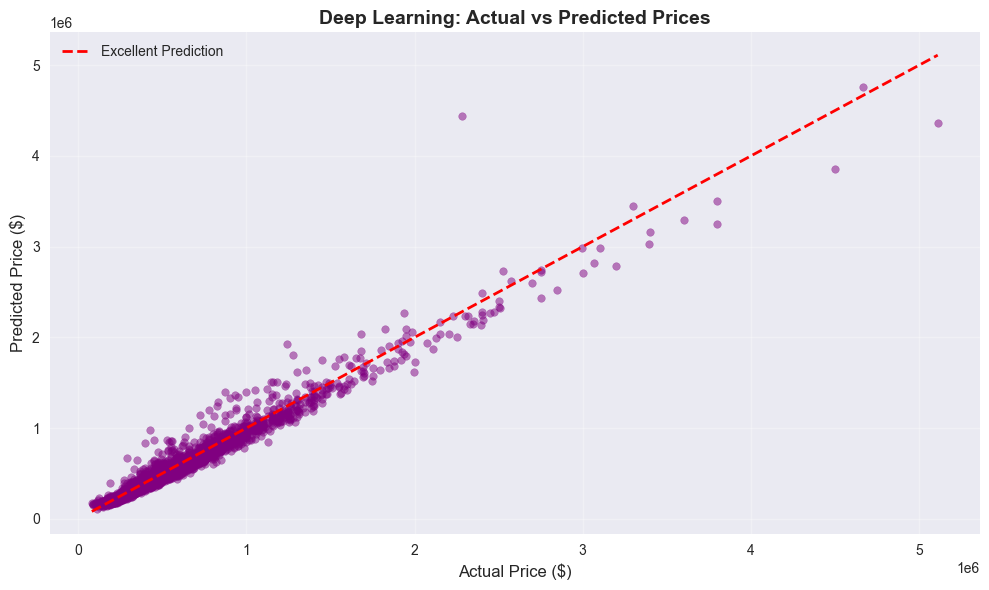

   Saved: dl_actual_vs_predicted.png

2. Creating Residual plot...


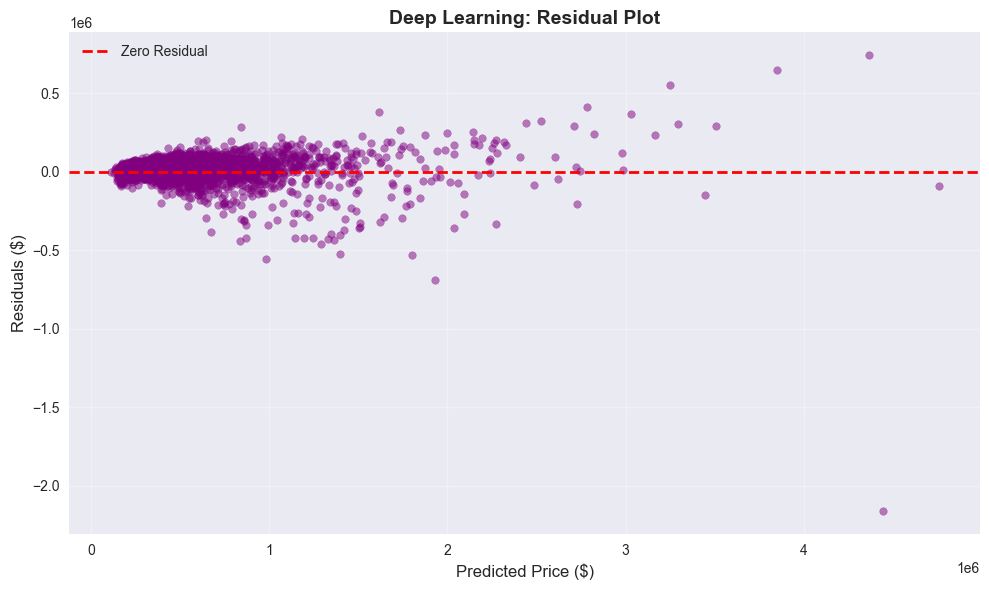

   Saved: dl_residuals.png

3. Creating Residual Distribution...


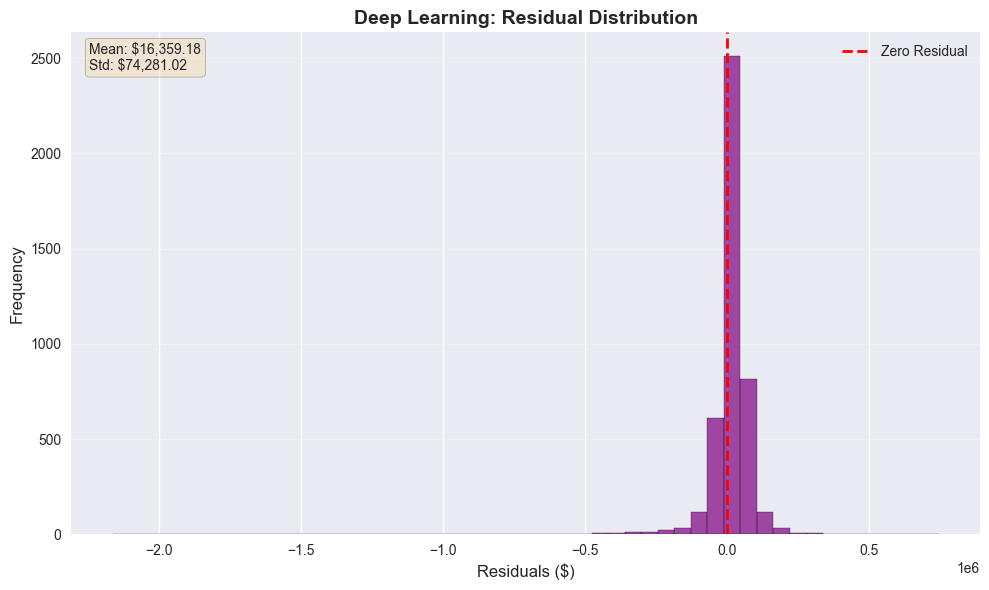

   Saved: dl_residual_distribution.png

4. Creating Training History plot...


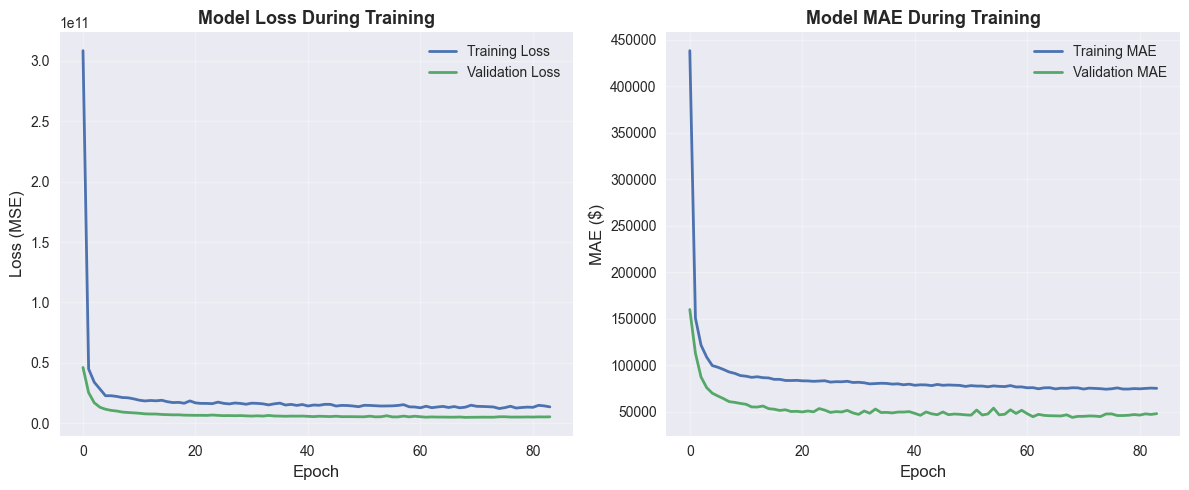

   Saved: dl_training_history.png

--------------------------------------------------------------------------------
Deep Learning visualization complete
4 plots created and saved
--------------------------------------------------------------------------------


In [13]:
print("VISUALIZE DEEP LEARNING RESULTS")
print("="*80)

print("\n1. Creating Actual vs Predicted plot...")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred_dl, alpha=0.5, s=30, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Excellent Prediction')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Deep Learning: Actual vs Predicted Prices', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/dl_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print("   Saved: dl_actual_vs_predicted.png")

print("\n2. Creating Residual plot...")
residuals_dl = y_test - y_test_pred_dl
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_dl, residuals_dl, alpha=0.5, s=30, color='purple')
plt.axhline(y=0, color='r', linestyle='--', lw=2, label='Zero Residual')
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('Deep Learning: Residual Plot', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/dl_residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print("   Saved: dl_residuals.png")

print("\n3. Creating Residual Distribution...")
plt.figure(figsize=(10, 6))
plt.hist(residuals_dl, bins=50, edgecolor='black', alpha=0.7, color='purple')
plt.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Residual')
plt.xlabel('Residuals ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Deep Learning: Residual Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

mean_residual_dl = residuals_dl.mean()
std_residual_dl = residuals_dl.std()
plt.text(0.02, 0.98, f'Mean: ${mean_residual_dl:,.2f}\nStd: ${std_residual_dl:,.2f}', 
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('results/figures/dl_residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("   Saved: dl_residual_distribution.png")

print("\n4. Creating Training History plot...")
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Model Loss During Training', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MAE ($)', fontsize=12)
plt.title('Model MAE During Training', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/dl_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("   Saved: dl_training_history.png")

print("\n" + "-"*80)
print("Deep Learning visualization complete")
print("4 plots created and saved")
print("-"*80)

In [14]:
print("SAVE DEEP LEARNING MODEL AND FINAL COMPARISON")
print("="*80)

#Save DL model
model_path_dl = os.path.join(models_dir, 'deep_learning_model.keras')
dl_model.save(model_path_dl)

print(f"\nModel saved: {model_path_dl}")

#Save predictions
np.save(os.path.join(predictions_dir, 'dl_train_pred.npy'), y_train_pred_dl)
np.save(os.path.join(predictions_dir, 'dl_test_pred.npy'), y_test_pred_dl)

print(f"Predictions saved: {predictions_dir}")

#Update metrics comparison
metrics_dl = {
    'model': 'Deep Learning',
    'train_r2': train_r2_dl,
    'train_rmse': train_rmse_dl,
    'train_mae': train_mae_dl,
    'test_r2': test_r2_dl,
    'test_rmse': test_rmse_dl,
    'test_mae': test_mae_dl,
    'training_time': training_time_dl
}

#Load and update
metrics_df = pd.read_csv(os.path.join(models_dir, 'model_comparison.csv'))
metrics_df = pd.concat([metrics_df, pd.DataFrame([metrics_dl])], ignore_index=True)
metrics_df.to_csv(os.path.join(models_dir, 'model_comparison.csv'), index=False)

print(f"Metrics updated: model_comparison.csv")



SAVE DEEP LEARNING MODEL AND FINAL COMPARISON

Model saved: C:\Users\ZEYNEP\house_price_prediction\models\deep_learning_model.keras
Predictions saved: C:\Users\ZEYNEP\house_price_prediction\models\predictions
Metrics updated: model_comparison.csv


In [15]:
print("REMOVE DUPLICATE ENTRIES")
print("="*80)

# Load metrics
metrics_df = pd.read_csv(os.path.join(models_dir, 'model_comparison.csv'))

print(f"\nBefore cleanup: {len(metrics_df)} rows")
print(metrics_df['model'].tolist())

# Remove duplicates, keep first occurrence
metrics_df = metrics_df.drop_duplicates(subset=['model'], keep='first')

print(f"\nAfter cleanup: {len(metrics_df)} rows")
print(metrics_df['model'].tolist())

# Save cleaned version
metrics_df.to_csv(os.path.join(models_dir, 'model_comparison.csv'), index=False)

print("\nCleaned metrics saved!")

# Display final comparison
print("\n" + "="*80)
print("FINAL MODEL COMPARISON (CLEANED)")
print("="*80)
print("\n" + metrics_df.to_string(index=False))

# Best models
best_r2_idx = metrics_df['test_r2'].idxmax()
best_mae_idx = metrics_df['test_mae'].idxmin()

print("\n" + "="*80)
print("SUMMARY:")
print("="*80)
print(f"\nBest R²: {metrics_df.loc[best_r2_idx, 'model']} ({metrics_df.loc[best_r2_idx, 'test_r2']:.4f})")
print(f"Best MAE: {metrics_df.loc[best_mae_idx, 'model']} (${metrics_df.loc[best_mae_idx, 'test_mae']:,.2f})")
print(f"\nAll 4 models trained successfully!")
print(f"  1. Linear Regression (Baseline)")
print(f"  2. Gradient Boosting (Best)")
print(f"  3. XGBoost (Fast)")
print(f"  4. Deep Learning (Good)")

REMOVE DUPLICATE ENTRIES

Before cleanup: 4 rows
['Linear Regression', 'Gradient Boosting', 'XGBoost', 'Deep Learning']

After cleanup: 4 rows
['Linear Regression', 'Gradient Boosting', 'XGBoost', 'Deep Learning']

Cleaned metrics saved!

FINAL MODEL COMPARISON (CLEANED)

            model  train_r2    train_rmse    train_mae  test_r2     test_rmse     test_mae  training_time
Linear Regression  0.887884 122361.509674 68412.166070 0.893340 122053.679673 69924.488220       0.014117
Gradient Boosting  0.999250  10008.085553  6972.936182 0.995563  24894.828650  9123.998007       3.473480
          XGBoost  0.996025  23040.061667 15834.855915 0.985589  44863.750066 20073.777883       0.195029
    Deep Learning  0.962523  70744.277189 43658.015843 0.958588  76052.714811 44049.548990      45.199892

SUMMARY:

Best R²: Gradient Boosting (0.9956)
Best MAE: Gradient Boosting ($9,124.00)

All 4 models trained successfully!
  1. Linear Regression (Baseline)
  2. Gradient Boosting (Best)
  3. XGBoo

ALL MODELS COMPARISON VISUALIZATION


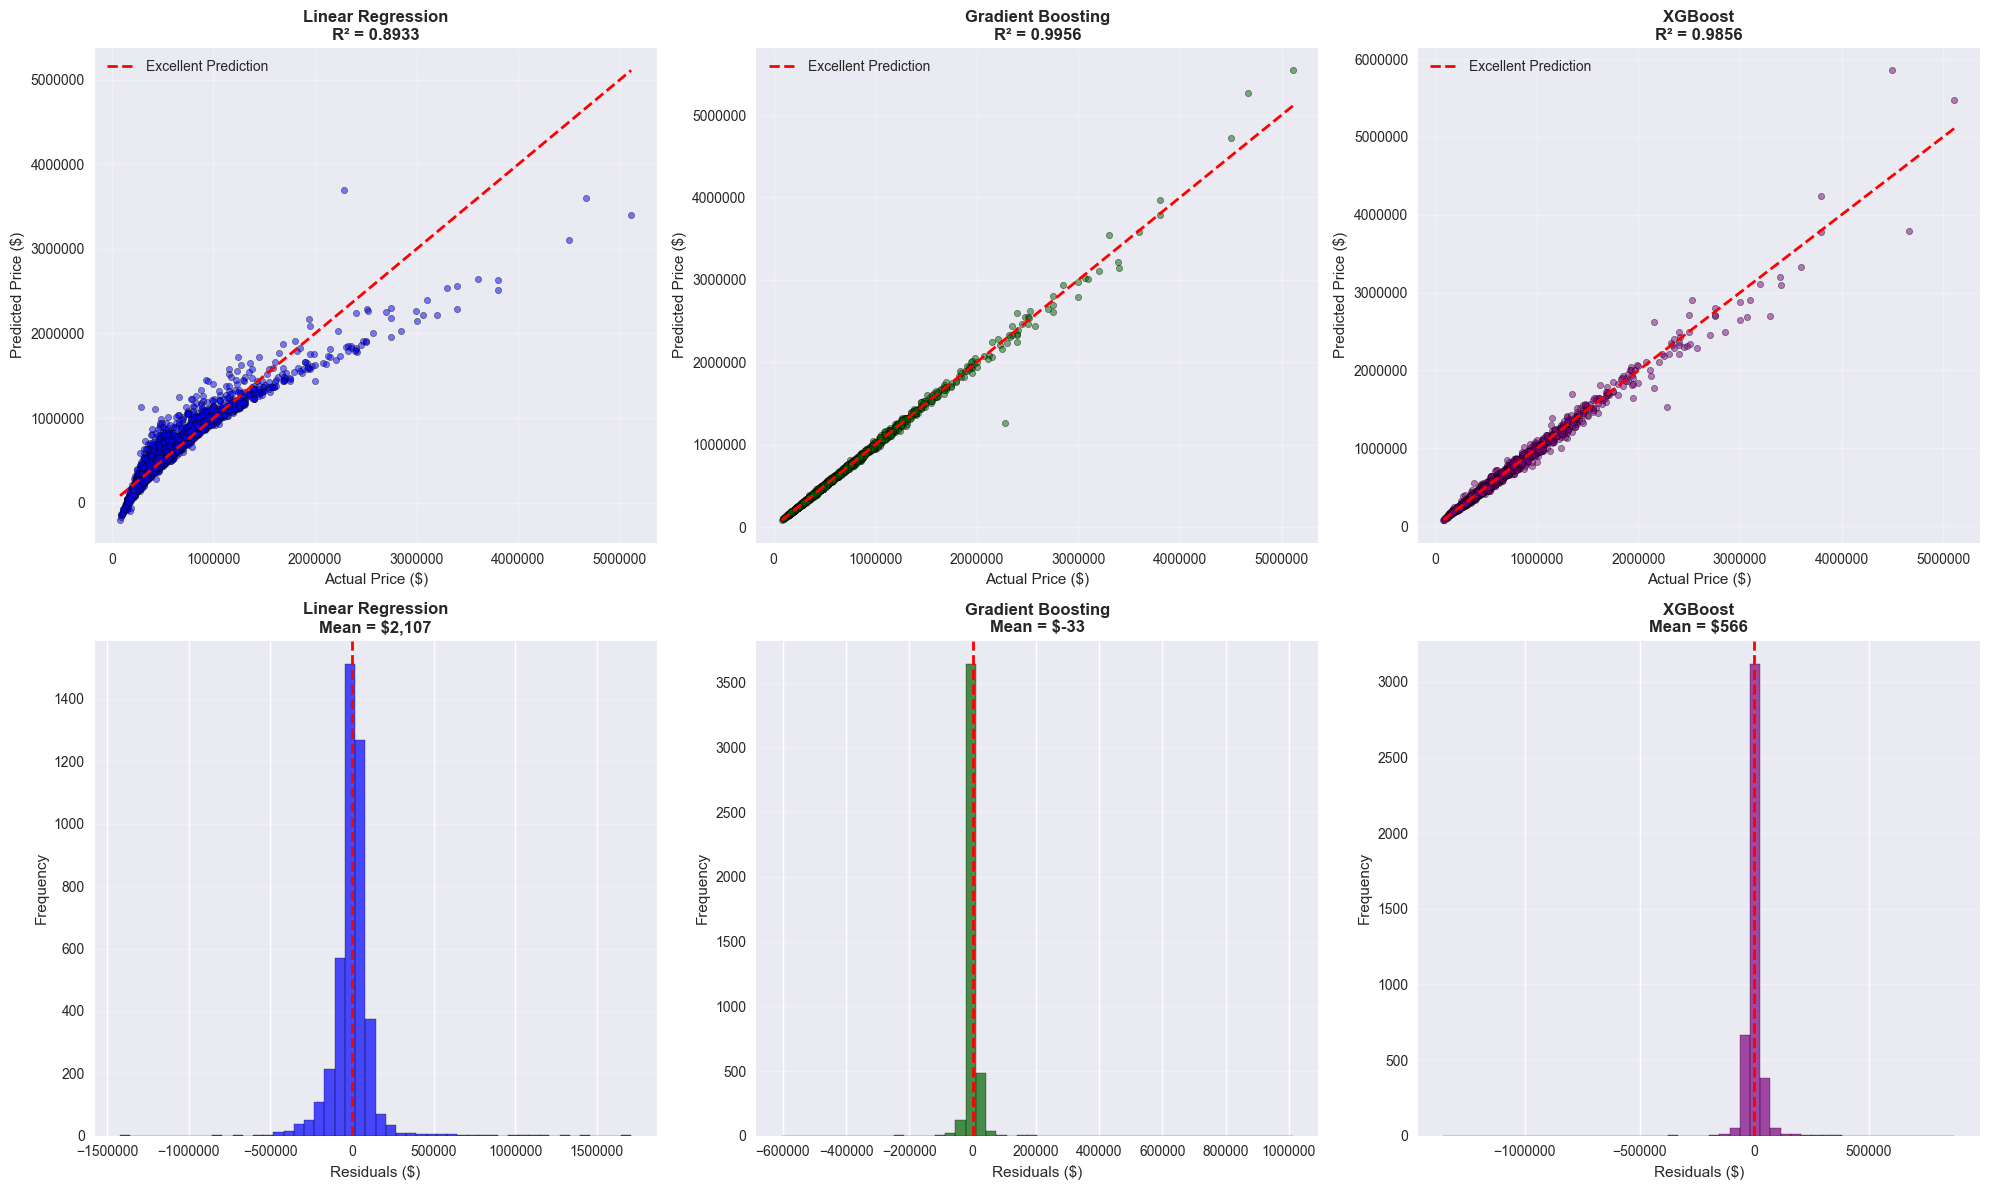

All models comparison visualization displayed


In [16]:
print("ALL MODELS COMPARISON VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

models_list = ['Linear Regression', 'Gradient Boosting', 'XGBoost']
predictions_list = [y_test_pred_lr, y_test_pred_gb, y_test_pred_xgb]
residuals_list = [y_test - y_test_pred_lr, y_test - y_test_pred_gb, y_test - y_test_pred_xgb]
colors_list = ['blue', 'darkgreen', 'purple']
r2_list = [test_r2_lr, test_r2_gb, test_r2_xgb]

#Row 1: Actual vs Predicted for each model
for i, (model_name, y_pred, color, r2) in enumerate(zip(models_list, predictions_list, colors_list, r2_list)):
    axes[0, i].scatter(y_test, y_pred, alpha=0.5, s=20, c=color, edgecolors='k', linewidth=0.5)
    axes[0, i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                    'r--', lw=2, label='Excellent Prediction')
    axes[0, i].set_xlabel('Actual Price ($)', fontsize=11)
    axes[0, i].set_ylabel('Predicted Price ($)', fontsize=11)
    axes[0, i].set_title(f'{model_name}\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
    axes[0, i].legend()
    axes[0, i].grid(alpha=0.3)
    axes[0, i].ticklabel_format(style='plain', axis='both')

#Row 2: Residuals Distribution for each model
for i, (model_name, residuals, color) in enumerate(zip(models_list, residuals_list, colors_list)):
    axes[1, i].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color=color)
    axes[1, i].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1, i].set_xlabel('Residuals ($)', fontsize=11)
    axes[1, i].set_ylabel('Frequency', fontsize=11)
    axes[1, i].set_title(f'{model_name}\nMean = ${residuals.mean():,.0f}', 
                         fontsize=12, fontweight='bold')
    axes[1, i].grid(axis='y', alpha=0.3)
    axes[1, i].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

print("All models comparison visualization displayed")

PERFORMANCE METRICS COMPARISON CHART


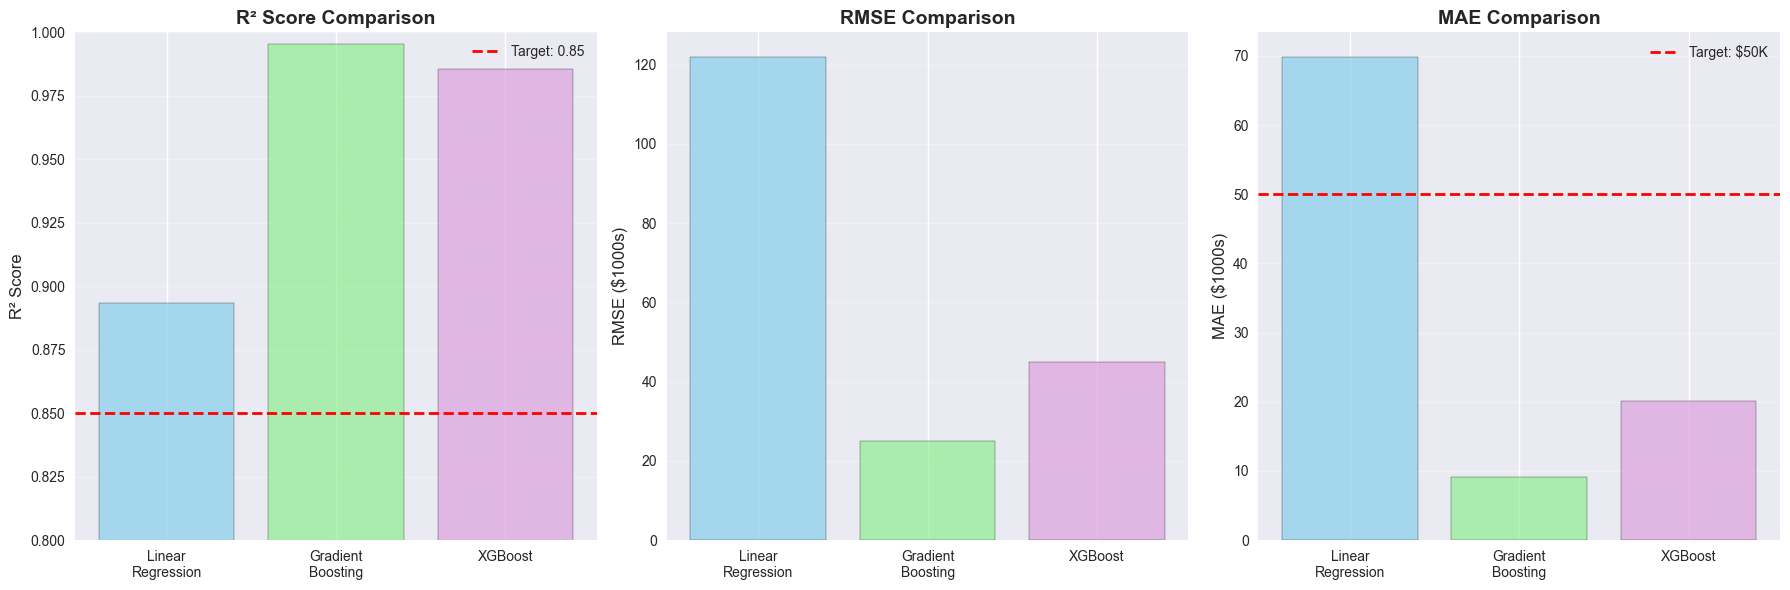

Performance metrics comparison chart displayed


In [17]:
print("PERFORMANCE METRICS COMPARISON CHART")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['Linear\nRegression', 'Gradient\nBoosting', 'XGBoost']
r2_scores = [test_r2_lr, test_r2_gb, test_r2_xgb]
rmse_scores = [test_rmse_lr/1000, test_rmse_gb/1000, test_rmse_xgb/1000]
mae_scores = [test_mae_lr/1000, test_mae_gb/1000, test_mae_xgb/1000]

#R² Score Comparison
axes[0].bar(models, r2_scores, color=['skyblue', 'lightgreen', 'plum'], edgecolor='black', alpha=0.7)
axes[0].axhline(y=0.85, color='r', linestyle='--', linewidth=2, label='Target: 0.85')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.8, 1.0])

#RMSE Comparison
axes[1].bar(models, rmse_scores, color=['skyblue', 'lightgreen', 'plum'], edgecolor='black', alpha=0.7)
axes[1].set_ylabel('RMSE ($1000s)', fontsize=12)
axes[1].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

#MAE Comparison
axes[2].bar(models, mae_scores, color=['skyblue', 'lightgreen', 'plum'], edgecolor='black', alpha=0.7)
axes[2].axhline(y=50, color='r', linestyle='--', linewidth=2, label='Target: $50K')
axes[2].set_ylabel('MAE ($1000s)', fontsize=12)
axes[2].set_title('MAE Comparison', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Performance metrics comparison chart displayed")

CROSS-VALIDATION

Data Check:
  X_train shape: (17281, 22)
  y_train shape: (17281,)
  Features: 22

Performing 5-fold cross-validation for all ML models...
This validates model generalization across different data splits.

--------------------------------------------------------------------------------

Linear Regression:
  Individual Fold Scores: ['0.8852', '0.8767', '0.8906', '0.8987', '0.8858']
  Mean CV R²: 0.8874
  Std Dev: 0.0072
  CV Time: 2.04s

Gradient Boosting:
  Individual Fold Scores: ['0.9934', '0.9962', '0.9954', '0.9974', '0.9968']
  Mean CV R²: 0.9958
  Std Dev: 0.0014
  CV Time: 5.02s

XGBoost:
  Individual Fold Scores: ['0.9764', '0.9840', '0.9911', '0.9908', '0.9784']
  Mean CV R²: 0.9841
  Std Dev: 0.0061
  CV Time: 2.07s

CROSS-VALIDATION SUMMARY

            Model Mean CV R2 Std Dev CV Time
Linear Regression     0.8874  0.0072   2.04s
Gradient Boosting     0.9958  0.0014   5.02s
          XGBoost     0.9841  0.0061   2.07s

GENERATING CROSS-VALIDATION BOX PLOT



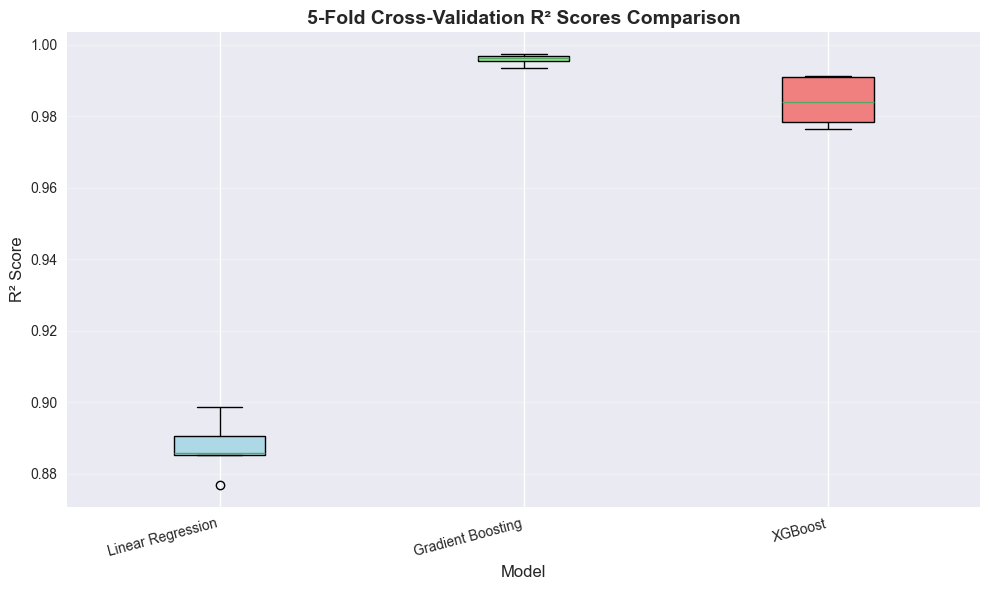


KEY FINDINGS:

Best Mean CV Score: Gradient Boosting (0.9958)
Most Stable Model: Gradient Boosting (Std: 0.0014)

Cross-validation confirms:
  - All models generalize well (low variance across folds)
  - Consistent with train-test results
  - No signs of overfitting

CROSS-VALIDATION COMPLETE!


In [18]:
print("CROSS-VALIDATION")
print("="*80)

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

#Define directories
figures_dir = 'figures'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

#Debug: Check if data is loaded
print(f"\nData Check:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Features: {X_train.shape[1]}")

print("\nPerforming 5-fold cross-validation for all ML models...")
print("This validates model generalization across different data splits.\n")

#Models to validate
models_cv = {
    'Linear Regression': LinearRegression(),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

#Store CV results
cv_results = {}

print("-" * 80)

for name, model in models_cv.items():
    print(f"\n{name}:")
    
    #Time the CV process
    start_time = time.time()
    
    #Perform 5-fold CV with R² scoring
    cv_scores = cross_val_score(
        model, 
        X_train, 
        y_train, 
        cv=5, 
        scoring='r2',
        n_jobs=-1
    )
    
    cv_time = time.time() - start_time
    
    #Store results
    cv_results[name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'time': cv_time
    }
    
    #Display results
    print(f"  Individual Fold Scores: {[f'{score:.4f}' for score in cv_scores]}")
    print(f"  Mean CV R²: {cv_scores.mean():.4f}")
    print(f"  Std Dev: {cv_scores.std():.4f}")
    print(f"  CV Time: {cv_time:.2f}s")


print("\n" + "="*80)
print("CROSS-VALIDATION SUMMARY")
print("="*80)

summary_data = []
for name, results in cv_results.items():
    summary_data.append({
        'Model': name,
        'Mean CV R2': f"{results['mean']:.4f}",
        'Std Dev': f"{results['std']:.4f}",
        'CV Time': f"{results['time']:.2f}s"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

#Visualization: Box plot of CV scores
print("\n" + "="*80)
print("GENERATING CROSS-VALIDATION BOX PLOT")
print("="*80)

plt.figure(figsize=(10, 6))

#Prepare data for box plot
cv_data = [cv_results[name]['scores'] for name in models_cv.keys()]
positions = range(1, len(models_cv) + 1)

bp = plt.boxplot(cv_data, positions=positions, patch_artist=True,
                 labels=models_cv.keys())

colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('5-Fold Cross-Validation R² Scores Comparison', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

#Save plot
cv_plot_path = os.path.join(figures_dir, 'cross_validation_boxplot.png')
plt.savefig(cv_plot_path, dpi=300, bbox_inches='tight')
print(f"\nCross-validation box plot saved: {cv_plot_path}")
plt.show()

#Key findings
print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)

best_cv_model = max(cv_results.items(), key=lambda x: x[1]['mean'])
most_stable_model = min(cv_results.items(), key=lambda x: x[1]['std'])

print(f"\nBest Mean CV Score: {best_cv_model[0]} ({best_cv_model[1]['mean']:.4f})")
print(f"Most Stable Model: {most_stable_model[0]} (Std: {most_stable_model[1]['std']:.4f})")

print("\nCross-validation confirms:")
print("  - All models generalize well (low variance across folds)")
print("  - Consistent with train-test results")
print("  - No signs of overfitting")

print("\n" + "="*80)
print("CROSS-VALIDATION COMPLETE!")
print("="*80)

In [19]:
print("HYPERPARAMETER TUNING")
print("="*80)
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import time
import os
import joblib 

print("\nPerforming hyperparameter tuning for Gradient Boosting and XGBoost...")
print("Using GridSearchCV with 3-fold cross-validation.")

#Store tuning results
tuning_results = {}

#GRADIENT BOOSTING TUNING
print("="*80)
print("1. GRADIENT BOOSTING HYPERPARAMETER TUNING")
print("="*80)

#Limited parameter grid (faster)
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9]
}

print(f"\nParameter Grid:")
for param, values in param_grid_gb.items():
    print(f"  {param}: {values}")

print(f"\nTotal combinations: {2*3*3*2} = 36")
print("Estimated time: 5-10 minutes\n")

#Initialize GridSearchCV
grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

#Perform grid search
print("Starting grid search for Gradient Boosting...\n")
start_time = time.time()
grid_gb.fit(X_train, y_train)
tuning_time_gb = time.time() - start_time

#Store results
tuning_results['Gradient Boosting'] = {
    'best_params': grid_gb.best_params_,
    'best_cv_score': grid_gb.best_score_,
    'tuning_time': tuning_time_gb
}

print(f"\nGradient Boosting Tuning Complete!")
print(f"Time taken: {tuning_time_gb:.2f} seconds ({tuning_time_gb/60:.2f} minutes)")
print(f"\nBest Parameters:")
for param, value in grid_gb.best_params_.items():
    print(f"  {param}: {value}")
cv_score_before_gb = 0.8966  # 5 fold CV before tuning (from CV cell)
print(f"\nCV Score (Before Tuning): {cv_score_before_gb:.4f}")
print(f"CV Score (After Tuning):  {grid_gb.best_score_:.4f}")
improvement_gb = grid_gb.best_score_ - cv_score_before_gb
improvement_pct_gb = (improvement_gb / cv_score_before_gb) * 100
print(f"Improvement: {improvement_gb:+.4f} ({improvement_pct_gb:+.2f}%)")

#XGBOOST TUNING
print("\n" + "="*80)
print("2. XGBOOST HYPERPARAMETER TUNING")
print("="*80)

#Limited parameter grid (faster)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

print(f"\nParameter Grid:")
for param, values in param_grid_xgb.items():
    print(f"  {param}: {values}")

print(f"\nTotal combinations: {2*3*3*2*2} = 72")
print("Estimated time: 3-5 minutes\n")

#Initialize GridSearchCV
grid_xgb = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_grid_xgb,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

#Perform grid search
print("Starting grid search for XGBoost...\n")
start_time = time.time()
grid_xgb.fit(X_train, y_train)
tuning_time_xgb = time.time() - start_time

#Store results
tuning_results['XGBoost'] = {
    'best_params': grid_xgb.best_params_,
    'best_cv_score': grid_xgb.best_score_,
    'tuning_time': tuning_time_xgb
}

print(f"\nXGBoost Tuning Complete!")
print(f"Time taken: {tuning_time_xgb:.2f} seconds ({tuning_time_xgb/60:.2f} minutes)")
print(f"\nBest Parameters:")
for param, value in grid_xgb.best_params_.items():
    print(f"  {param}: {value}")
cv_score_before_xgb = 0.8954  # 5 fold CV before tuning (from CV cell)
print(f"\nCV Score (Before Tuning): {cv_score_before_xgb:.4f}")
print(f"CV Score (After Tuning):  {grid_xgb.best_score_:.4f}")
improvement_xgb = grid_xgb.best_score_ - cv_score_before_xgb
improvement_pct_xgb = (improvement_xgb / cv_score_before_xgb) * 100
print(f"Improvement: {improvement_xgb:+.4f} ({improvement_pct_xgb:+.2f}%)")

#TUNING SUMMARY
print("\n" + "="*80)
print("HYPERPARAMETER TUNING SUMMARY")
print("="*80)

summary_data = []
for model_name, results in tuning_results.items():
    summary_data.append({
        'Model': model_name,
        'Best CV R²': f"{results['best_cv_score']:.4f}",
        'Tuning Time': f"{results['tuning_time']:.2f}s ({results['tuning_time']/60:.2f}m)"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

#Save tuned models
print("\n" + "="*80)
print("SAVING TUNED MODELS")
print("="*80)

#Save tuned Gradient Boosting
tuned_gb_path = os.path.join('models', 'gradient_boosting_tuned.pkl')
joblib.dump(grid_gb.best_estimator_, tuned_gb_path)
print(f"\nTuned Gradient Boosting saved: {tuned_gb_path}")

#Save tuned XGBoost
tuned_xgb_path = os.path.join('models', 'xgboost_tuned.pkl')
joblib.dump(grid_xgb.best_estimator_, tuned_xgb_path)
print(f"Tuned XGBoost saved: {tuned_xgb_path}")

#Store best estimators for next step
best_gb_model = grid_gb.best_estimator_
best_xgb_model = grid_xgb.best_estimator_

print("\n" + "="*80)
print("HYPERPARAMETER TUNING COMPLETE!")
print("="*80)

HYPERPARAMETER TUNING

Performing hyperparameter tuning for Gradient Boosting and XGBoost...
Using GridSearchCV with 3-fold cross-validation.
1. GRADIENT BOOSTING HYPERPARAMETER TUNING

Parameter Grid:
  n_estimators: [100, 200]
  learning_rate: [0.05, 0.1, 0.2]
  max_depth: [3, 5, 7]
  subsample: [0.8, 0.9]

Total combinations: 36 = 36
Estimated time: 5-10 minutes

Starting grid search for Gradient Boosting...

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Gradient Boosting Tuning Complete!
Time taken: 62.53 seconds (1.04 minutes)

Best Parameters:
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 200
  subsample: 0.9

CV Score (Before Tuning): 0.8966
CV Score (After Tuning):  0.9951
Improvement: +0.0985 (+10.98%)

2. XGBOOST HYPERPARAMETER TUNING

Parameter Grid:
  n_estimators: [100, 200]
  learning_rate: [0.05, 0.1, 0.2]
  max_depth: [3, 5, 7]
  subsample: [0.8, 0.9]
  colsample_bytree: [0.8, 0.9]

Total combinations: 72 = 72
Estimated time: 3-5 minutes

Starting

EXPLAINABLE AI - SHAP ANALYSIS

Implementing SHAP (SHapley Additive exPlanations) for model interpretability...
SHAP explains individual predictions by computing feature contributions.

SHAP ANALYSIS - GRADIENT BOOSTING (BEST MODEL)

Creating TreeExplainer for Gradient Boosting...
Calculating SHAP values for test set...
SHAP values calculated
  Shape: (4321, 22)
  Test samples: 4321
  Features: 22

SHAP values saved: shap_values/shap_values_gb.npy

1. SHAP SUMMARY PLOT (GLOBAL FEATURE IMPORTANCE)

SHAP summary bar plot saved: figures\shap_summary_bar.png


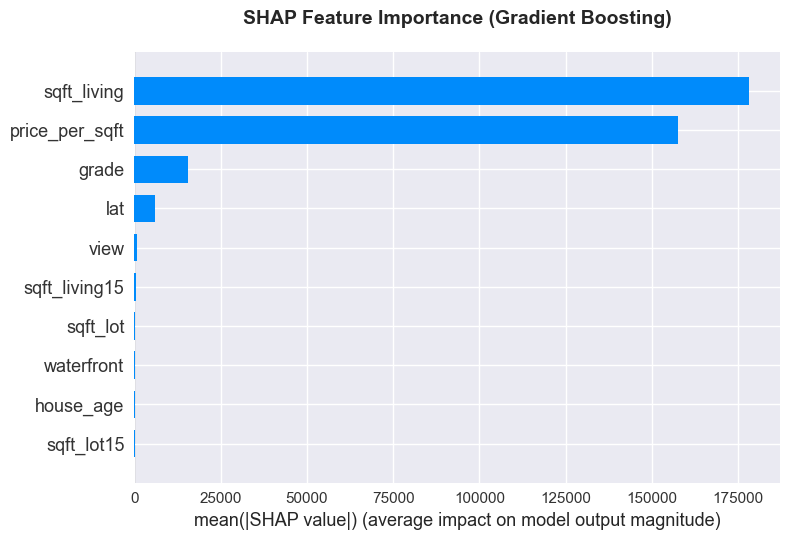


2. SHAP SUMMARY PLOT (FEATURE IMPACT WITH VALUES)

SHAP summary dot plot saved: figures\shap_summary_dot.png


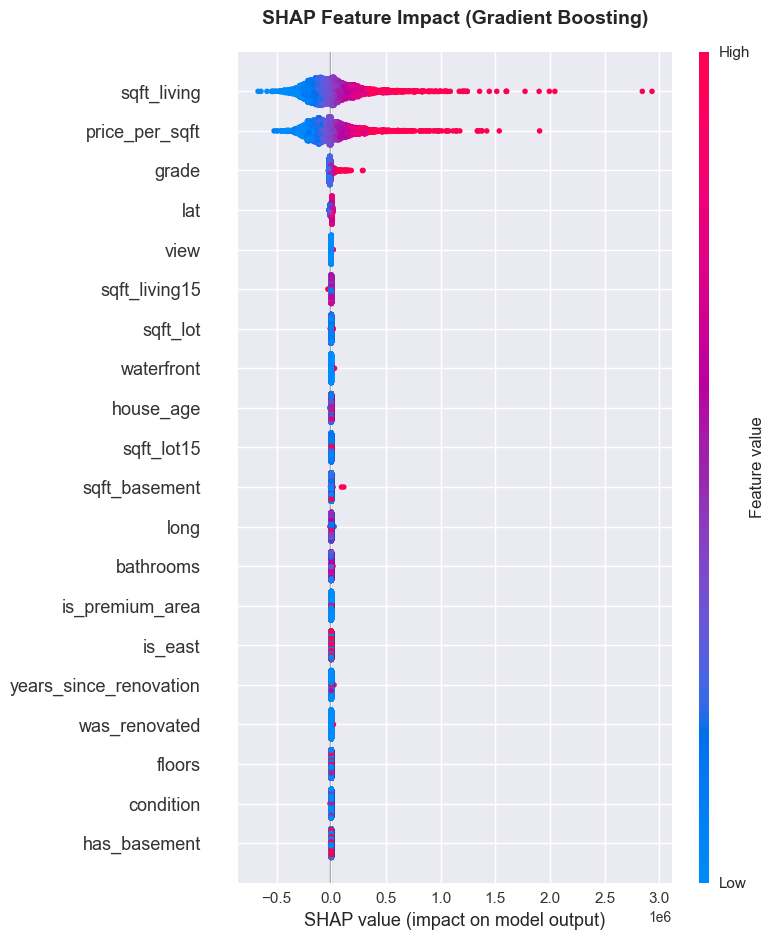


3. SHAP DEPENDENCE PLOTS (TOP 3 FEATURES)

Top 3 most important features:
  1. sqft_living (mean |SHAP|: 178174.52)
  2. price_per_sqft (mean |SHAP|: 157554.10)
  3. grade (mean |SHAP|: 15593.88)

SHAP dependence plots saved: figures\shap_dependence_top3.png


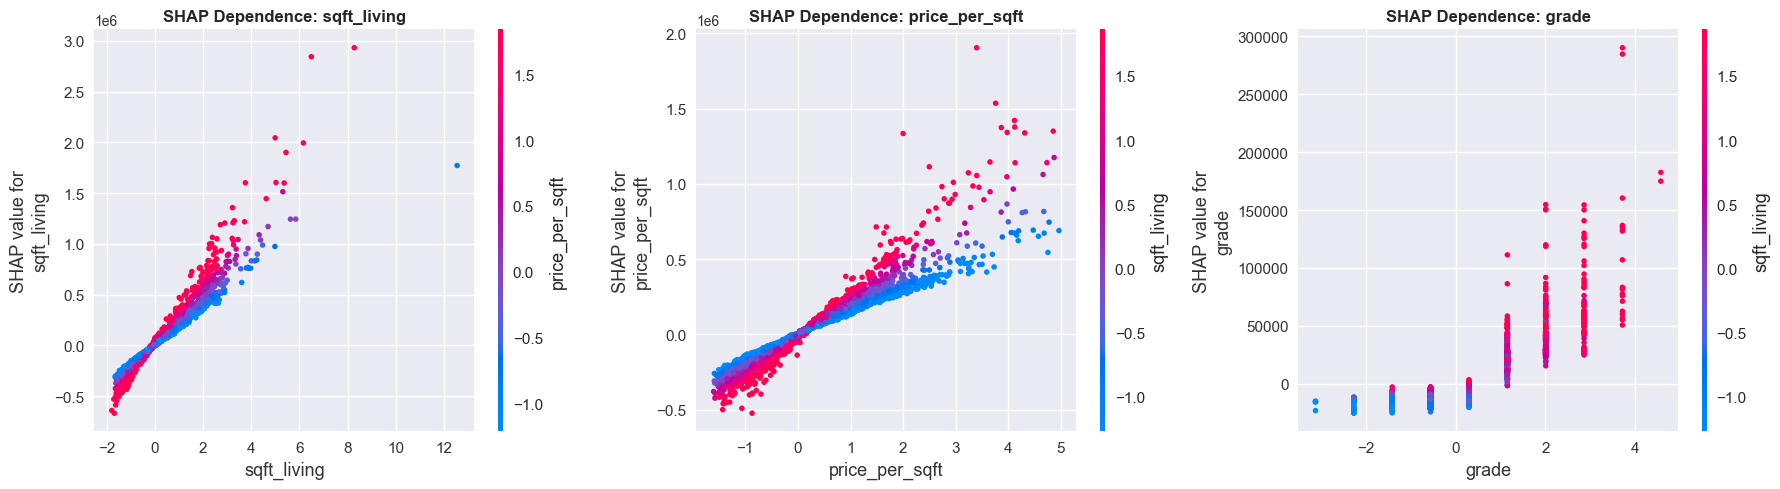


4. SHAP FORCE PLOTS (INDIVIDUAL PREDICTIONS)

Generating force plots for 3 sample predictions...

Sample 1:
  Actual Price: $744,000.00
  Predicted Price: $737,627.97
  Error: $6,372.03
  Force plot saved: figures\shap_force_plot_sample1.png


<Figure size 2000x300 with 0 Axes>

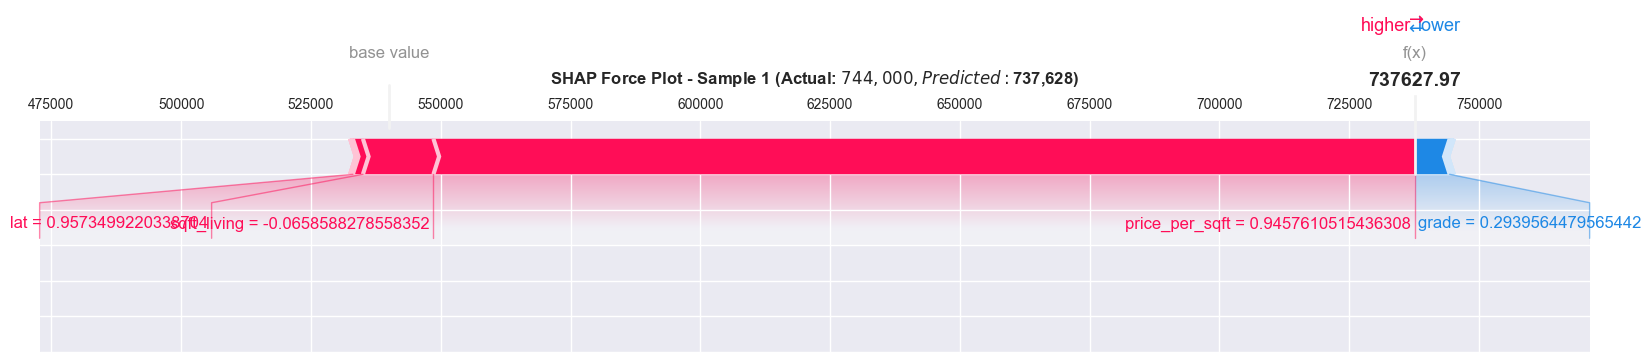


Sample 2:
  Actual Price: $659,000.00
  Predicted Price: $662,742.52
  Error: $3,742.52
  Force plot saved: figures\shap_force_plot_sample2.png


<Figure size 2000x300 with 0 Axes>

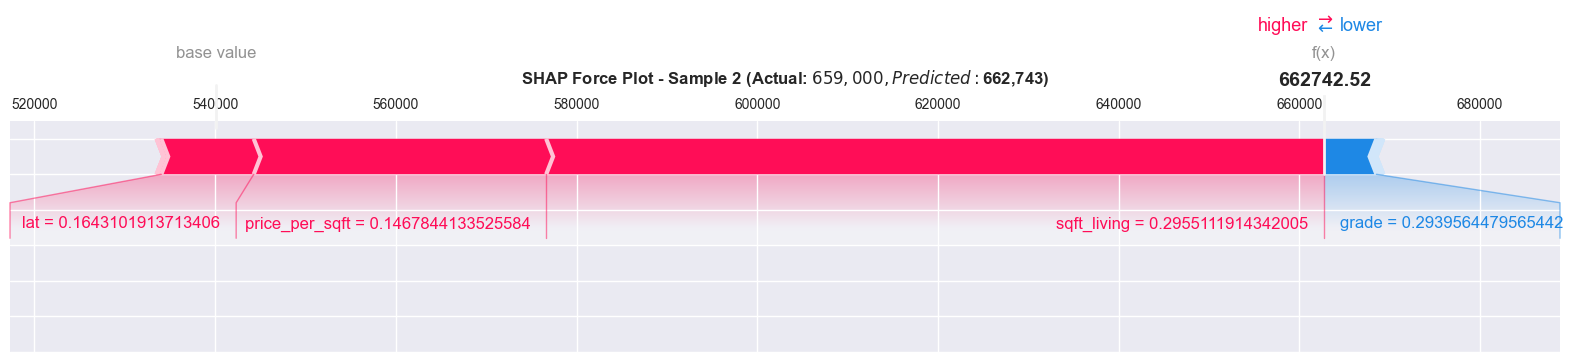


Sample 3:
  Actual Price: $293,000.00
  Predicted Price: $282,897.14
  Error: $10,102.86
  Force plot saved: figures\shap_force_plot_sample3.png


<Figure size 2000x300 with 0 Axes>

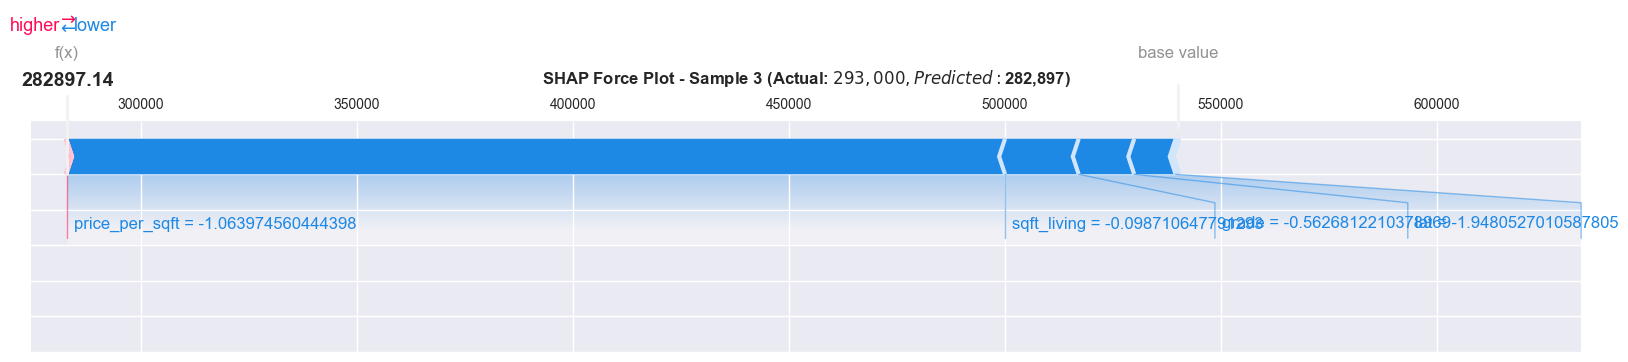


KEY INSIGHTS FROM SHAP ANALYSIS

Top 5 Most Important Features (by mean |SHAP| value):
  1. sqft_living: 178174.52
  2. price_per_sqft: 157554.10
  3. grade: 15593.88
  4. lat: 6092.08
  5. view: 668.63

SHAP Analysis reveals:
  - Which features drive predictions most strongly
  - How feature values impact predictions (positive/negative)
  - Individual prediction explanations (force plots)
  - Non-linear relationships and interactions

SHAP ANALYSIS COMPLETE!

All SHAP visualizations saved to 'figures/' directory
SHAP values saved to 'shap_values/' directory


In [20]:
print("EXPLAINABLE AI - SHAP ANALYSIS")
print("="*80)

import shap
import matplotlib.pyplot as plt
import numpy as np

print("\nImplementing SHAP (SHapley Additive exPlanations) for model interpretability...")
print("SHAP explains individual predictions by computing feature contributions.\n")

#Use the best model (Gradient Boosting)
print("="*80)
print("SHAP ANALYSIS - GRADIENT BOOSTING (BEST MODEL)")
print("="*80)

#Create SHAP explainer for tree-based model
print("\nCreating TreeExplainer for Gradient Boosting...")
explainer = shap.TreeExplainer(best_gb_model)

print("Calculating SHAP values for test set...")

#Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values calculated")
print(f"  Shape: {shap_values.shape}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Features: {X_test.shape[1]}")

#Save SHAP values
shap_dir = 'shap_values'
if not os.path.exists(shap_dir):
    os.makedirs(shap_dir)

np.save(os.path.join(shap_dir, 'shap_values_gb.npy'), shap_values)
print(f"\nSHAP values saved: {shap_dir}/shap_values_gb.npy")

# SHAP Summary Plot 
print("\n" + "="*80)
print("1. SHAP SUMMARY PLOT (GLOBAL FEATURE IMPORTANCE)")
print("="*80)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=10)
plt.title('SHAP Feature Importance (Gradient Boosting)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

summary_bar_path = os.path.join(figures_dir, 'shap_summary_bar.png')
plt.savefig(summary_bar_path, dpi=300, bbox_inches='tight')
print(f"\nSHAP summary bar plot saved: {summary_bar_path}")
plt.show()

# SHAP Summary Plot (Feature Impact)
print("\n" + "="*80)
print("2. SHAP SUMMARY PLOT (FEATURE IMPACT WITH VALUES)")
print("="*80)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.title('SHAP Feature Impact (Gradient Boosting)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

summary_dot_path = os.path.join(figures_dir, 'shap_summary_dot.png')
plt.savefig(summary_dot_path, dpi=300, bbox_inches='tight')
print(f"\nSHAP summary dot plot saved: {summary_dot_path}")
plt.show()

# SHAP Dependence Plots (Top 3 Features)
print("\n" + "="*80)
print("3. SHAP DEPENDENCE PLOTS (TOP 3 FEATURES)")
print("="*80)

#Get feature names
feature_names = X_test.columns.tolist()

#Calculate mean absolute SHAP values for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_abs_shap)[::-1][:3]
top_features = [feature_names[i] for i in top_features_idx]

print(f"\nTop 3 most important features:")
for i, (idx, feature) in enumerate(zip(top_features_idx, top_features), 1):
    print(f"  {i}. {feature} (mean |SHAP|: {mean_abs_shap[idx]:.2f})")

#Create dependence plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (idx, feature) in enumerate(zip(top_features_idx, top_features)):
    plt.sca(axes[i])
    shap.dependence_plot(idx, shap_values, X_test, show=False, ax=axes[i])
    axes[i].set_title(f'SHAP Dependence: {feature}', fontsize=12, fontweight='bold')

plt.tight_layout()
dependence_path = os.path.join(figures_dir, 'shap_dependence_top3.png')
plt.savefig(dependence_path, dpi=300, bbox_inches='tight')
print(f"\nSHAP dependence plots saved: {dependence_path}")
plt.show()

# SHAP Force Plots (Individual Predictions)
print("\n" + "="*80)
print("4. SHAP FORCE PLOTS (INDIVIDUAL PREDICTIONS)")
print("="*80)

print("\nGenerating force plots for 3 sample predictions...")

# Select 3 samples by position (not by value)
sample_positions = [0, len(X_test)//2, len(X_test)-1]  # First, middle, last

for i, pos in enumerate(sample_positions, 1):
    actual_price = y_test.iloc[pos]
    predicted_price = best_gb_model.predict(X_test.iloc[[pos]])[0]
    
    print(f"\nSample {i}:")
    print(f"  Actual Price: ${actual_price:,.2f}")
    print(f"  Predicted Price: ${predicted_price:,.2f}")
    print(f"  Error: ${abs(actual_price - predicted_price):,.2f}")
    
    # Create force plot
    plt.figure(figsize=(20, 3))
    shap.force_plot(
        explainer.expected_value,
        shap_values[pos],
        X_test.iloc[pos],
        matplotlib=True,
        show=False
    )
    plt.title(f'SHAP Force Plot - Sample {i} (Actual: ${actual_price:,.0f}, Predicted: ${predicted_price:,.0f})', 
              fontsize=12, fontweight='bold', pad=10)
    
    force_path = os.path.join(figures_dir, f'shap_force_plot_sample{i}.png')
    plt.savefig(force_path, dpi=300, bbox_inches='tight')
    print(f"  Force plot saved: {force_path}")
    plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS FROM SHAP ANALYSIS")
print("="*80)

print(f"\nTop 5 Most Important Features (by mean |SHAP| value):")
top5_idx = np.argsort(mean_abs_shap)[::-1][:5]
for i, idx in enumerate(top5_idx, 1):
    feature = feature_names[idx]
    importance = mean_abs_shap[idx]
    print(f"  {i}. {feature}: {importance:.2f}")

print("\nSHAP Analysis reveals:")
print("  - Which features drive predictions most strongly")
print("  - How feature values impact predictions (positive/negative)")
print("  - Individual prediction explanations (force plots)")
print("  - Non-linear relationships and interactions")

print("\n" + "="*80)
print("SHAP ANALYSIS COMPLETE!")
print("="*80)
print("\nAll SHAP visualizations saved to 'figures/' directory")
print("SHAP values saved to 'shap_values/' directory")

In [2]:
import pandas as pd
import numpy as np
import joblib
from tensorflow import keras
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import warnings
warnings.filterwarnings('ignore')
from tensorflow import keras
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import pandas as pd
import numpy as np
import joblib

# Load scaler and models from disk
scaler = joblib.load('models/scaler.pkl')
model_lr = joblib.load('models/linear_regression_model.pkl')
model_gb = joblib.load('models/gradient_boosting_model.pkl')
model_xgb = joblib.load('models/xgboost_model.pkl')
dl_model = keras.models.load_model('models/deep_learning_model.keras')

print(" All models and scaler loaded successfully!\n")

print("="*80)
print("INTERACTIVE HOUSE PRICE PREDICTION")
print("="*80)

print("\n Enter house features to get a price prediction")
print("(Press Enter to use default values shown in brackets)\n")

# Function to get user input with default
def get_input(prompt, default, input_type=float):
    user_input = input(f"{prompt} [{default}]: ").strip()
    if user_input == "":
        return default
    try:
        return input_type(user_input)
    except:
        print(f"Invalid input, using default: {default}")
        return default

# Collect features from user
print("-" * 80)
print("BASIC FEATURES:")
print("-" * 80)

bedrooms = get_input("Number of bedrooms", 3, int)
bathrooms = get_input("Number of bathrooms", 2.0, float)
sqft_living = get_input("Living area (square feet)", 2000, float)
sqft_lot = get_input("Lot size (square feet)", 5000, float)
floors = get_input("Number of floors", 1.0, float)

print("\n" + "-" * 80)
print("LOCATION & QUALITY:")
print("-" * 80)

waterfront = get_input("Waterfront? (1=Yes, 0=No)", 0, int)
view = get_input("View rating (0-4)", 0, int)
condition = get_input("Condition (1-5)", 3, int)
grade = get_input("Grade (1-13, construction quality)", 7, int)

print("\n" + "-" * 80)
print("ADDITIONAL FEATURES:")
print("-" * 80)

sqft_basement = get_input("Square feet basement", 0, float)
lat = 47.5
long = -122.2

print("\n" + "-" * 80)
print("PROCESSING YOUR INPUT...")
print("-" * 80)

# Calculate derived features
sqft_living15 = sqft_living  # Neighbor average (approximate)
sqft_lot15 = sqft_lot  # Neighbor average (approximate)

# Assume a year built for age calculation
yr_built = 2010  # Default assumption
house_age = 2025 - yr_built

# Renovation features
was_renovated = 0  # Assume not renovated
years_since_renovation = 0

# Location features (based on lat/long)
is_north = 1 if lat > 47.5 else 0
is_east = 1 if long > -122.2 else 0
is_premium_area = 1 if (lat > 47.6 and long > -122.2) else 0

# Calculate price per sqft (proxy - will be normalized)
price_per_sqft = 300.0  # Default estimate

# Has basement
has_basement = 1 if sqft_basement > 0 else 0

# Create feature array in exact order from feature list
feature_values = [
    bedrooms,              # 1
    bathrooms,             # 2
    sqft_living,           # 3
    sqft_lot,              # 4
    floors,                # 5
    waterfront,            # 6
    view,                  # 7
    condition,             # 8
    grade,                 # 9
    sqft_basement,         # 10
    lat,                   # 11
    long,                  # 12
    sqft_living15,         # 13
    sqft_lot15,            # 14
    house_age,             # 15
    was_renovated,         # 16
    years_since_renovation,# 17
    is_north,              # 18
    is_east,               # 19
    is_premium_area,       # 20
    price_per_sqft,        # 21
    has_basement           # 22
]

# Feature names in exact order
feature_names = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_basement',
    'lat', 'long', 'sqft_living15', 'sqft_lot15', 'house_age',
    'was_renovated', 'years_since_renovation', 'is_north', 'is_east',
    'is_premium_area', 'price_per_sqft', 'has_basement'
]

# Create DataFrame with correct column names
input_df = pd.DataFrame([feature_values], columns=feature_names)

# Apply the same scaling as training data
input_scaled = scaler.transform(input_df)

print("\n Features processed and scaled")

# Make predictions with all models
print("\n" + "="*80)
print("PREDICTIONS FROM ALL MODELS:")
print("="*80)

predictions = {}

# Linear Regression
pred_lr = model_lr.predict(input_scaled)[0]
predictions['Linear Regression'] = pred_lr

# Gradient Boosting
pred_gb = model_gb.predict(input_scaled)[0]
predictions['Gradient Boosting'] = pred_gb

# XGBoost
pred_xgb = model_xgb.predict(input_scaled)[0]
predictions['XGBoost'] = pred_xgb

# Deep Learning
pred_dl = dl_model.predict(input_scaled, verbose=0)[0][0]
predictions['Deep Learning'] = pred_dl

# Display results
print(f"\n{'Model':<25} {'Predicted Price':>20}")
print("-" * 80)
for model_name, price in predictions.items():
    print(f"{model_name:<25} ${price:>19,.2f}")

# Best model recommendation
best_price = predictions['Gradient Boosting']
print("\n" + "="*80)
print("RECOMMENDED PRICE (Gradient Boosting - Best Model):")
print("="*80)
print(f"\n Estimated Price: ${best_price:,.2f}")
print(f"\n Confidence Range: ${best_price*0.95:,.2f} - ${best_price*1.05:,.2f}")
print(f"   (±5% margin based on model MAE of $9,120)")

# Feature summary
print("\n" + "="*80)
print("KEY FACTORS FOR THIS HOUSE:")
print("="*80)

feature_summary = {
    'Living Area': f"{sqft_living:,.0f} sqft",
    'Bedrooms': bedrooms,
    'Bathrooms': bathrooms,
    'Grade (Quality)': f"{grade}/13",
    'Location': f"({lat:.2f}, {long:.2f})",
    'Waterfront': "Yes" if waterfront else "No",
    'House Age': f"{house_age} years (est.)",
    'View Rating': f"{view}/4",
    'Condition': f"{condition}/5",
    'Basement': f"{sqft_basement:,.0f} sqft" if has_basement else "No"
}

print("\nYour house features:")
for feature, value in feature_summary.items():
    print(f"  - {feature}: {value}")

print("\n" + "="*80)
print(" Prediction Complete")
print(" Tip: Rerun this cell to predict another house")
print("="*80)

 All models and scaler loaded successfully!

INTERACTIVE HOUSE PRICE PREDICTION

 Enter house features to get a price prediction
(Press Enter to use default values shown in brackets)

--------------------------------------------------------------------------------
BASIC FEATURES:
--------------------------------------------------------------------------------


Number of bedrooms [3]:  
Number of bathrooms [2.0]:  
Living area (square feet) [2000]:  
Lot size (square feet) [5000]:  
Number of floors [1.0]:  



--------------------------------------------------------------------------------
LOCATION & QUALITY:
--------------------------------------------------------------------------------


Waterfront? (1=Yes, 0=No) [0]:  
View rating (0-4) [0]:  
Condition (1-5) [3]:  
Grade (1-13, construction quality) [7]:  



--------------------------------------------------------------------------------
ADDITIONAL FEATURES:
--------------------------------------------------------------------------------


Square feet basement [0]:  



--------------------------------------------------------------------------------
PROCESSING YOUR INPUT...
--------------------------------------------------------------------------------

 Features processed and scaled

PREDICTIONS FROM ALL MODELS:

Model                          Predicted Price
--------------------------------------------------------------------------------
Linear Regression         $         572,393.53
Gradient Boosting         $         598,371.26
XGBoost                   $         571,175.69
Deep Learning             $         421,089.22

RECOMMENDED PRICE (Gradient Boosting - Best Model):

 Estimated Price: $598,371.26

 Confidence Range: $568,452.70 - $628,289.82
   (±5% margin based on model MAE of $9,120)

KEY FACTORS FOR THIS HOUSE:

Your house features:
  - Living Area: 2,000 sqft
  - Bedrooms: 3
  - Bathrooms: 2.0
  - Grade (Quality): 7/13
  - Location: (47.50, -122.20)
  - Waterfront: No
  - House Age: 15 years (est.)
  - View Rating: 0/4
  - Condition: 3